# Project 2 - Classification - Decision Trees

**In this file:** 
+ Data Preparation + Modeling - Decision Trees 
 

=== 

**On other files:**
+ Business Understanding + Data Undertanding + Evaluation (of analyzed models).  *File Name:* ML_02_Business..ipynb 
+ Model Decision Trees.  *File Name:* ML_02_Model_DecisionTrees.ipynb
+ Model K-Nearest Neighbor (KNN).  *File Name:* ML_Model_KNN.ipynb
+ Model Logistic Regression.  *File Name:* ML_02_Model_LogisticR.ipynb
+ Models: Support Vector Machine (SVM), Neural networks and Naïve Bayes.  *File Name:* ML_02_Model_SVN_NN_NB.ipynb


===

#### **Group V**
+ Ana Isabel Moura, 20250168
+ Ayoub Mask, 20250183
+ Beatriz Lobão, 20250566
+ Joao Bernardino, 20250922
+ Lara Pereira, 20250921

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
import pickle
warnings.filterwarnings('ignore')

# Sklearn
from sklearn.tree import (
    DecisionTreeClassifier, export_text, plot_tree
)
from sklearn.model_selection import (
    train_test_split, StratifiedKFold,
    cross_val_score, GridSearchCV
)
from sklearn.metrics import (
    confusion_matrix, classification_report, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve
)

RANDOM_STATE = 42
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})
sns.set_style('whitegrid')
print('Libraries loaded.')

Libraries loaded.


## Data Preparation 

In [2]:
#Load Data
df = pd.read_excel('/Users/anamoura/Desktop/MachineLearning/Project_02/campaign.xlsx')
print(f'Shape: {df.shape}')
df.describe(include='all').T

Shape: (2240, 29)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ID,2240.0,NaN,NaN,NaN,5592.159821,3246.662198,0.0,2828.25,5458.5,8427.75,11191.0
Year_Birth,2240.0,NaN,NaN,NaN,1968.805804,11.984069,1893.0,1959.0,1970.0,1977.0,1996.0
Education,2240,5,Graduation,1127,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Marital_Status,2240,8,Married,864,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Income,2216.0,NaN,NaN,NaN,52247.251354,25173.076661,1730.0,35303.0,51381.5,68522.0,666666.0
Kidhome,2240.0,NaN,NaN,NaN,0.444196,0.538398,0.0,0.0,0.0,1.0,2.0
Teenhome,2240.0,NaN,NaN,NaN,0.50625,0.544538,0.0,0.0,0.0,1.0,2.0
Dt_Customer,2240,665,2012-08-31,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Recency,2240.0,NaN,NaN,NaN,49.109375,28.962453,0.0,24.0,49.0,74.0,99.0
MntWines,2237.0,NaN,NaN,NaN,303.838623,336.576209,0.0,24.0,173.0,504.0,1493.0


In [3]:
#Create a data copy 
df_prep = df.copy()

#### Missing Values

In [4]:
#Check missing values
print(df_prep.isnull().sum()[df_prep.isnull().sum() > 0])

Income          24
MntWines         3
MntFruits        2
MntGoldProds    53
dtype: int64


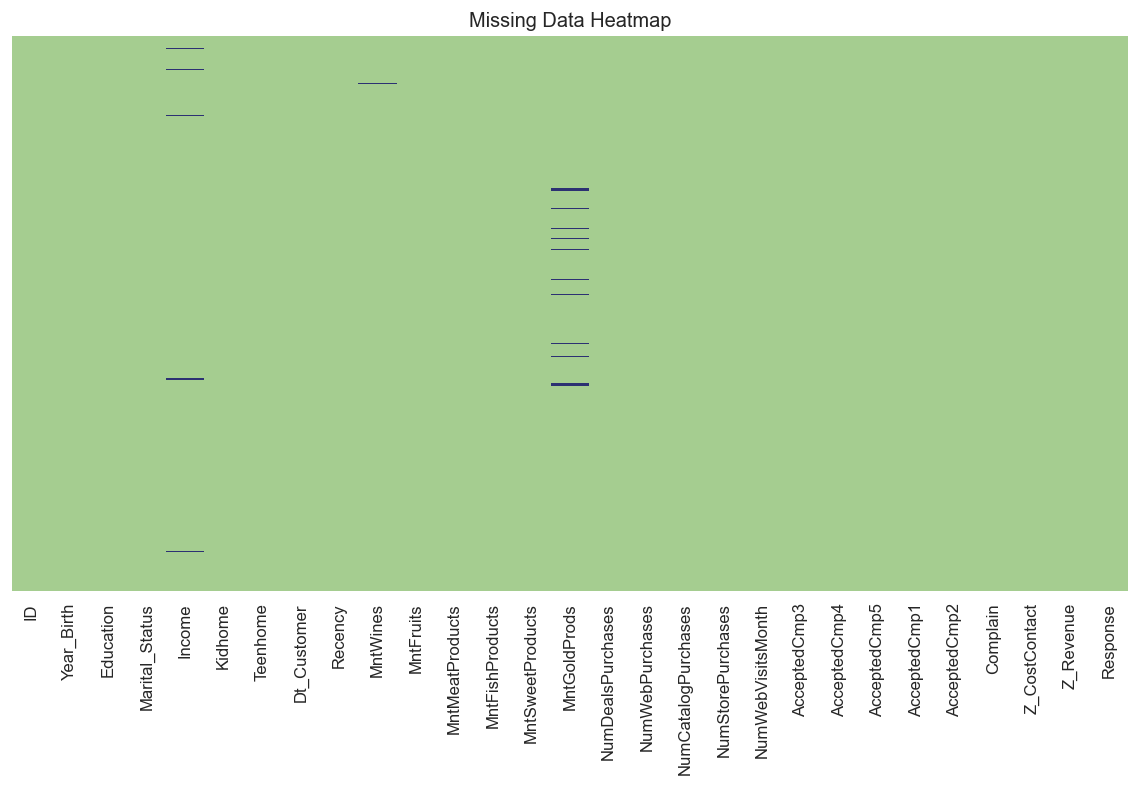

In [5]:
#Heatmap of missing values
plt.figure(figsize=(12, 6))
sns.heatmap(df_prep.isnull(), yticklabels=False, cbar=False, cmap='crest')
plt.title('Missing Data Heatmap')
plt.show()

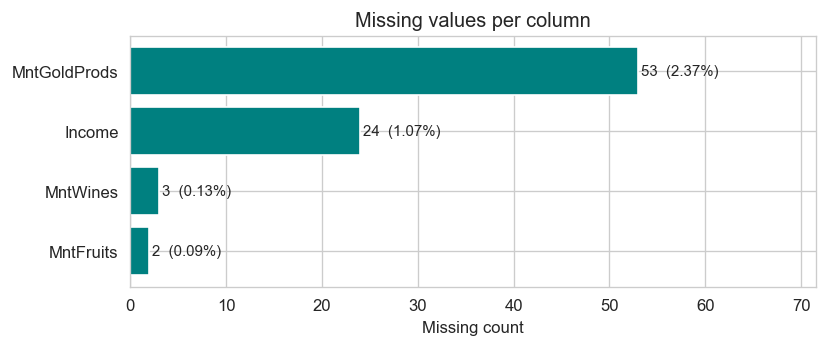

In [6]:
missing = df_prep.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=True)
pct = (missing / len(df) * 100).round(2)

fig, ax = plt.subplots(figsize=(7, 3))
bars = ax.barh(missing.index, missing.values, color='teal')

for bar, count, p in zip(bars, missing.values, pct.values):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{count}  ({p}%)', va='center', fontsize=9)

ax.set_xlabel('Missing count')
ax.set_title('Missing values per column')
ax.set_xlim(0, missing.max() * 1.35)
plt.tight_layout()
plt.show()

Observations: 
Missing values on Income, MntGoldProds, MntWines and MntFruits. 
MntWines and MntFruits change with median. 
Check Income and MntGoldProds - Possible use k-means to replace missing information

#### MntWines and MntFruits Values

In [7]:
#Impute MntWines and MntFruits missing values with median
for col in ['MntWines', 'MntFruits']:
    df_prep[col] = df_prep[col].fillna(df_prep[col].median())

In [8]:
remaining_missing = df_prep.isnull().sum()
print(remaining_missing[remaining_missing > 0])

Income          24
MntGoldProds    53
dtype: int64


#### Gold Products

In [9]:
display(df_prep['MntGoldProds'].describe())

count    2187.000000
mean       44.596251
std        52.419487
min         0.000000
25%         9.000000
50%        25.000000
75%        57.000000
max       362.000000
Name: MntGoldProds, dtype: float64

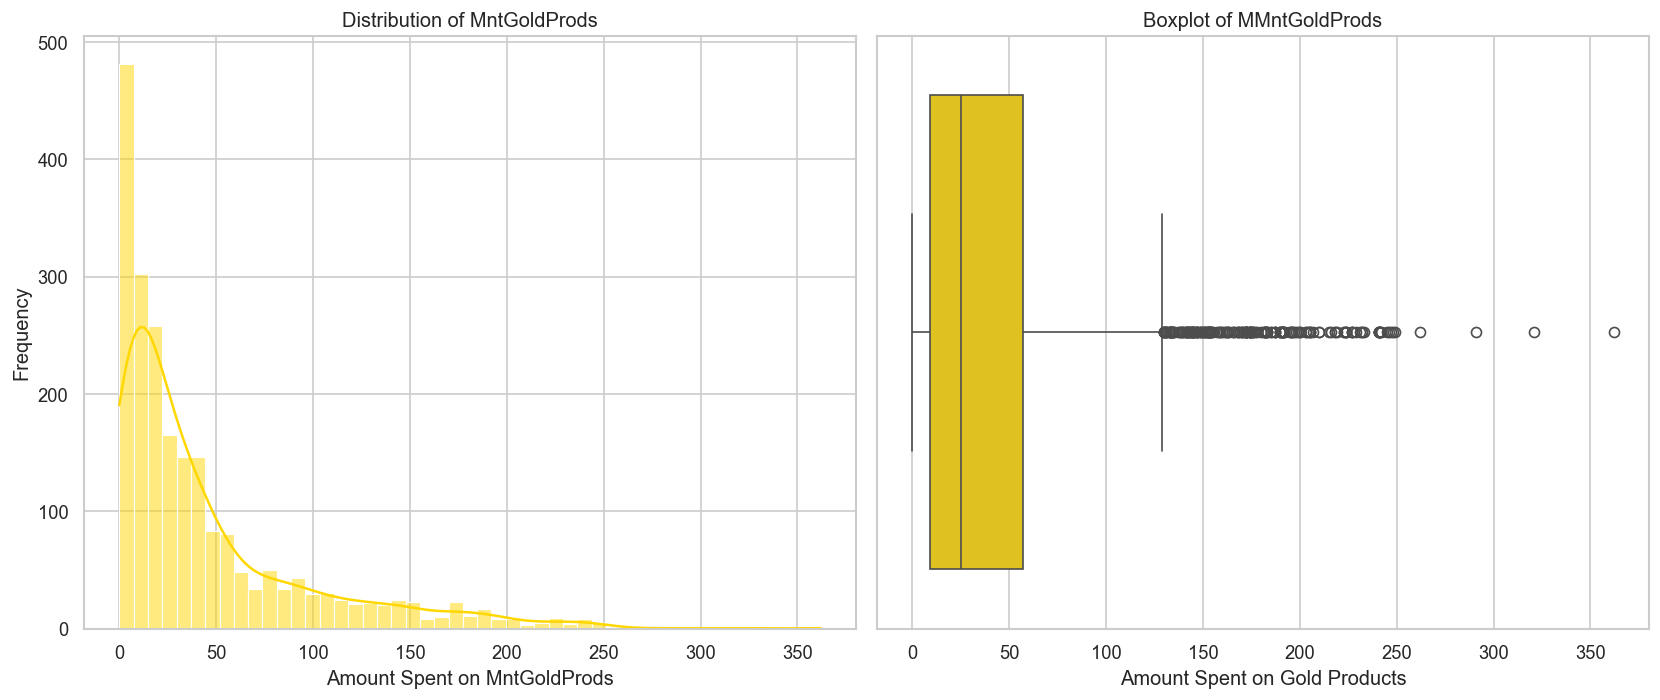

In [10]:
#Check MntGoldProds distribution 

# Visualize MntGoldProds
sns.set_theme(style="whitegrid")

# Create a figure with a Histogram and a Boxplot
plt.figure(figsize=(14, 6))

#Histogram 
plt.subplot(1, 2, 1)
sns.histplot(df_prep['MntGoldProds'], kde=True, color='gold')
plt.title('Distribution of MntGoldProds')
plt.xlabel('Amount Spent on MntGoldProds')
plt.ylabel('Frequency')

#Boxplot
plt.subplot(1, 2, 2)
sns.boxplot(x=df_prep['MntGoldProds'], color='gold')
plt.title('Boxplot of MMntGoldProds')
plt.xlabel('Amount Spent on Gold Products')

plt.tight_layout()
plt.show()

In [11]:
#Check MntGoldProds Outliers 

gold_99 = df_prep['MntGoldProds'].quantile(0.99)
print(f'MntGoldProds 99th percentile: {gold_99:,.0f}')

MntGoldProds 99th percentile: 227


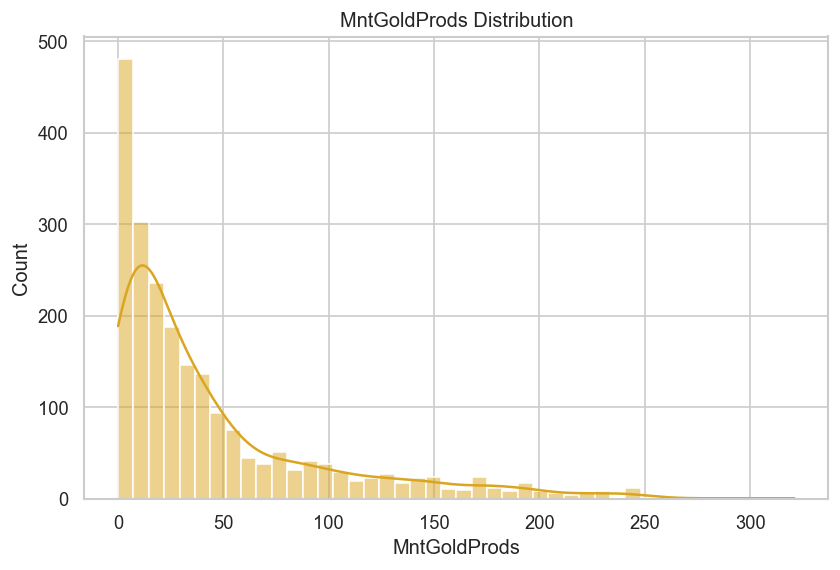

In [12]:
#Check All the Values on MntGoldProds Overview distribution 

# Filter data for visualization only
df_gold = df_prep[df_prep['MntGoldProds'] < 350]

plt.figure(figsize=(8, 5))
sns.histplot(df_gold['MntGoldProds'], kde=True, color='goldenrod')
plt.title('MntGoldProds Distribution')
plt.show()

In [13]:
#Clip outliers in MntGoldProds

df_prep['MntGoldProds'] = df_prep['MntGoldProds'].clip(upper=gold_99)
print(f'Gold Products max after clipping: {df_prep["MntGoldProds"].max():,.0f}')

Gold Products max after clipping: 227


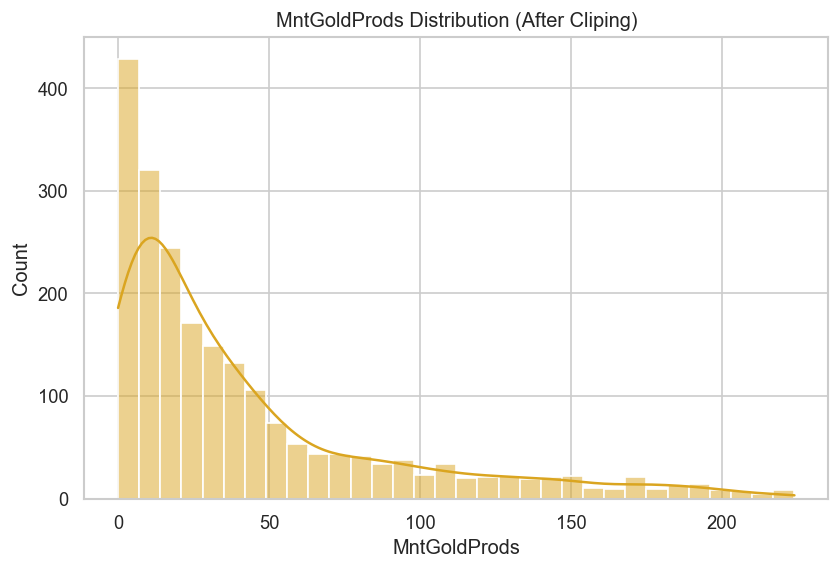

In [14]:
#Check All the Values on MntGoldProd after Cliping

# Filter data for visualization only
df_gold = df_prep[df_prep['MntGoldProds'] < 227]

plt.figure(figsize=(8, 5))
sns.histplot(df_gold['MntGoldProds'], kde=True, color='goldenrod')
plt.title('MntGoldProds Distribution (After Cliping)')
plt.show()

#### MntFishProducts Variable

In [15]:
display(df_prep['MntFishProducts'].describe())

count    2240.000000
mean       37.523661
std        54.630198
min        -1.000000
25%         3.000000
50%        12.000000
75%        50.000000
max       259.000000
Name: MntFishProducts, dtype: float64

In [16]:
#Total amount for each unique values in MntFishProducts
value_counts = df_prep['MntFishProducts'].value_counts()
print("Frequency of each spending amount:")
print(value_counts.head())

Frequency of each spending amount:
MntFishProducts
0    383
2    155
3    130
4    108
6     82
Name: count, dtype: int64


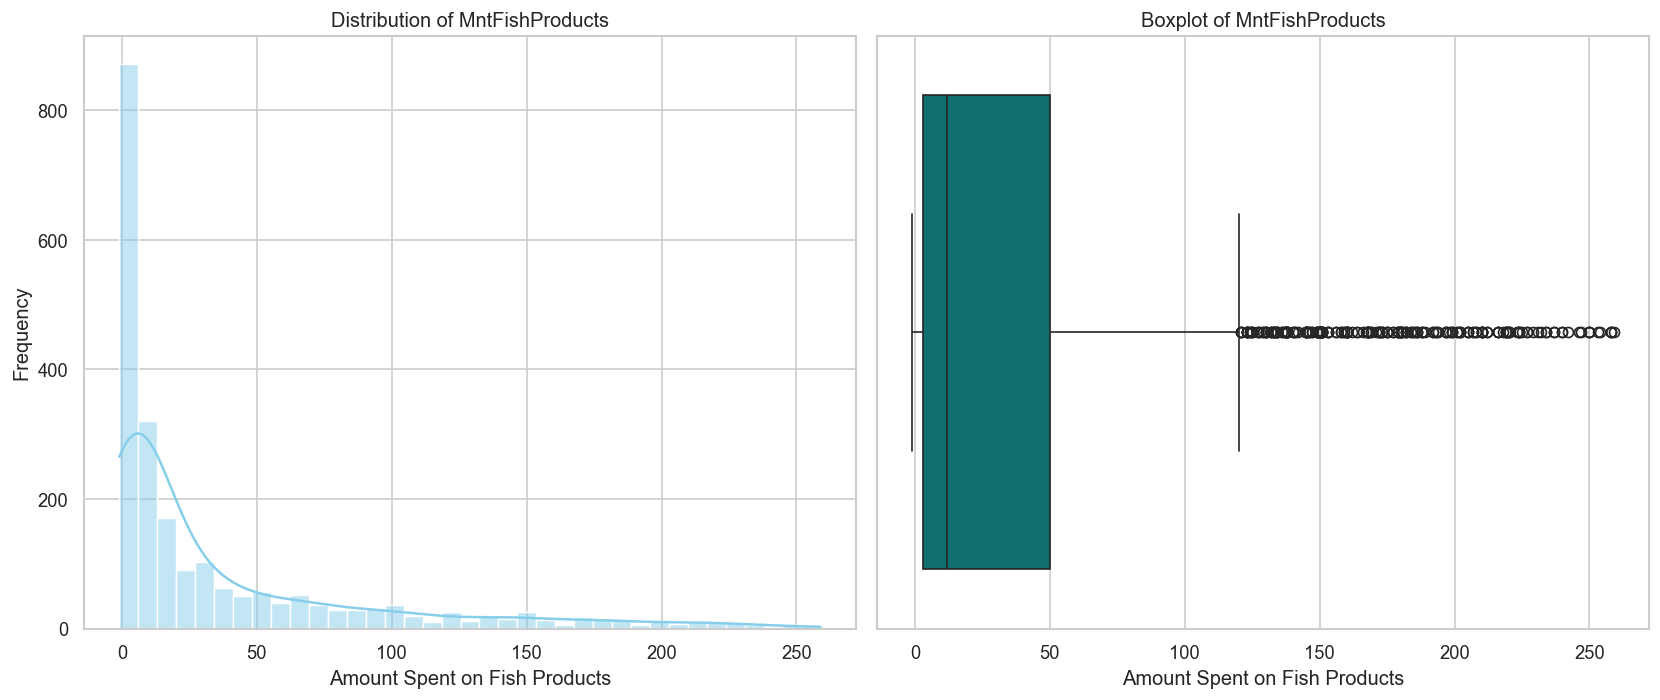

In [17]:
# Visualize MntFishProducts
sns.set_theme(style="whitegrid")

# Create a figure with a Histogram and a Boxplot
plt.figure(figsize=(14, 6))

#Histogram 
plt.subplot(1, 2, 1)
sns.histplot(df_prep['MntFishProducts'], kde=True, color='skyblue')
plt.title('Distribution of MntFishProducts')
plt.xlabel('Amount Spent on Fish Products')
plt.ylabel('Frequency')

#Boxplot
plt.subplot(1, 2, 2)
sns.boxplot(x=df_prep['MntFishProducts'], color='teal')
plt.title('Boxplot of MntFishProducts')
plt.xlabel('Amount Spent on Fish Products')

plt.tight_layout()
plt.show()

In [18]:
#Fix Invalid Fish Spending
df_prep.loc[df_prep['MntFishProducts'] < 0, 'MntFishProducts'] = 0

### Income

In [19]:
display(df_prep['Income'].describe())

count      2216.000000
mean      52247.251354
std       25173.076661
min        1730.000000
25%       35303.000000
50%       51381.500000
75%       68522.000000
max      666666.000000
Name: Income, dtype: float64

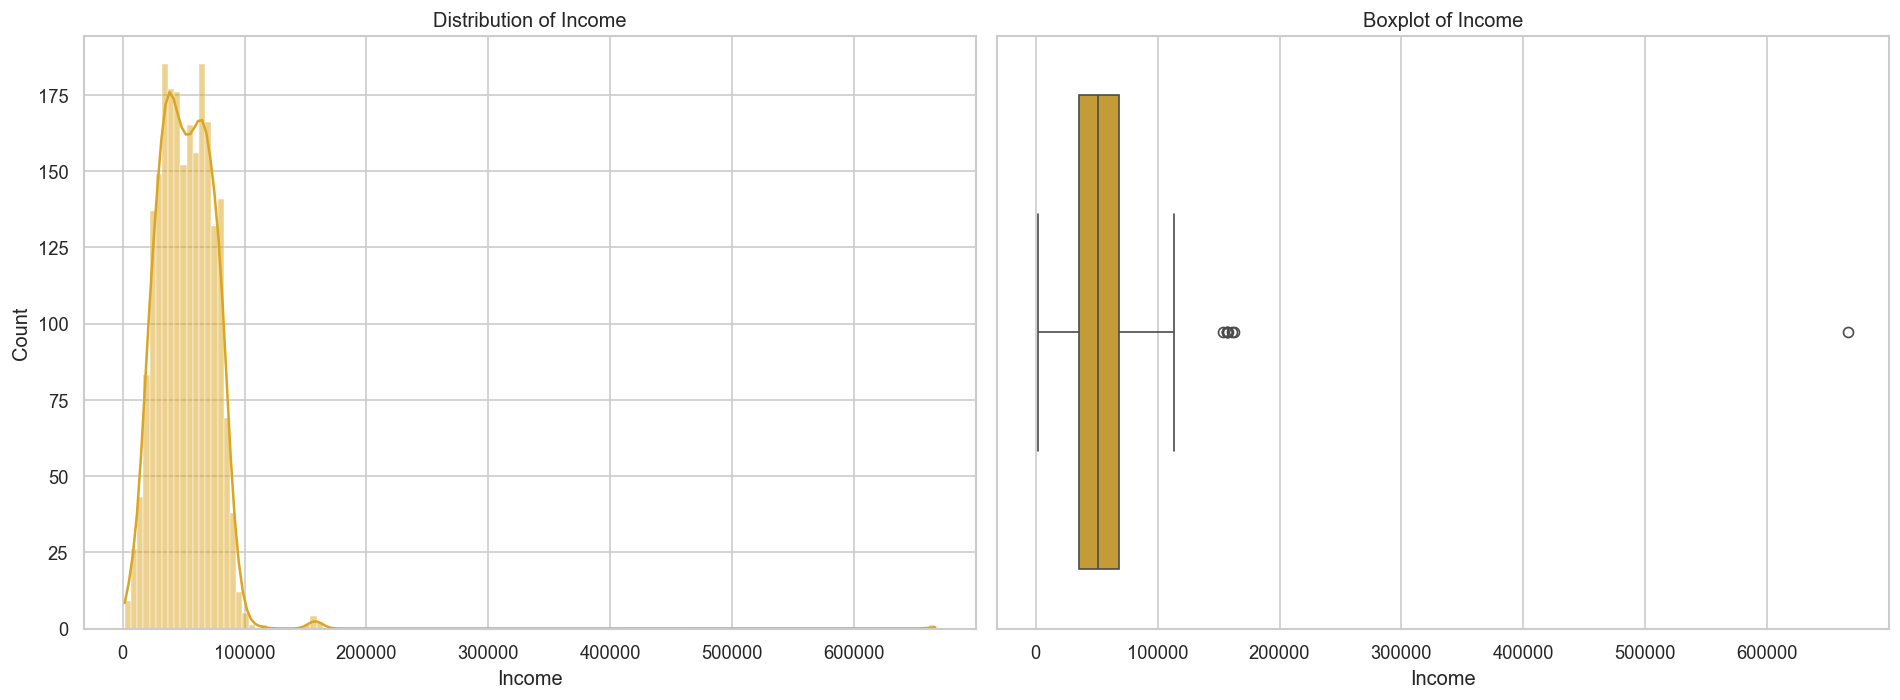

In [20]:
#View Income status

sns.set_theme(style="whitegrid")
plt.figure(figsize=(16, 6))

#Histogram 
plt.subplot(1, 2, 1)
sns.histplot(df_prep['Income'].dropna(), kde=True, color='goldenrod')
plt.title('Distribution of Income')
plt.xlabel('Income')

# Boxplot 
plt.subplot(1, 2, 2)
sns.boxplot(x=df_prep['Income'], color='goldenrod')
plt.title('Boxplot of Income')
plt.xlabel('Income')

plt.tight_layout()
plt.show()

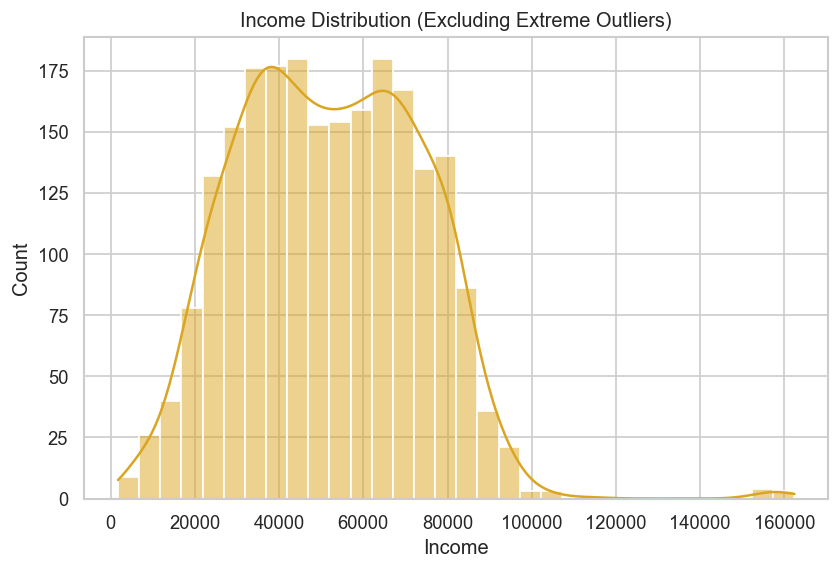

In [21]:
# Filter data for visualization only
df_income = df_prep[df_prep['Income'] < 200000]

plt.figure(figsize=(8, 5))
sns.histplot(df_income['Income'], kde=True, color='goldenrod')
plt.title('Income Distribution (Excluding Extreme Outliers)')
plt.show()

In [22]:
#Check Income Outliers 

income_99 = df_prep['Income'].quantile(0.99)
print(f'Income 99th percentile: {income_99:,.0f}')

Income 99th percentile: 94,459


In [23]:
#Clip outliers in income

df_prep['Income'] = df_prep['Income'].clip(upper=income_99)
print(f'Income max after clipping: {df_prep["Income"].max():,.0f}')

Income max after clipping: 94,459


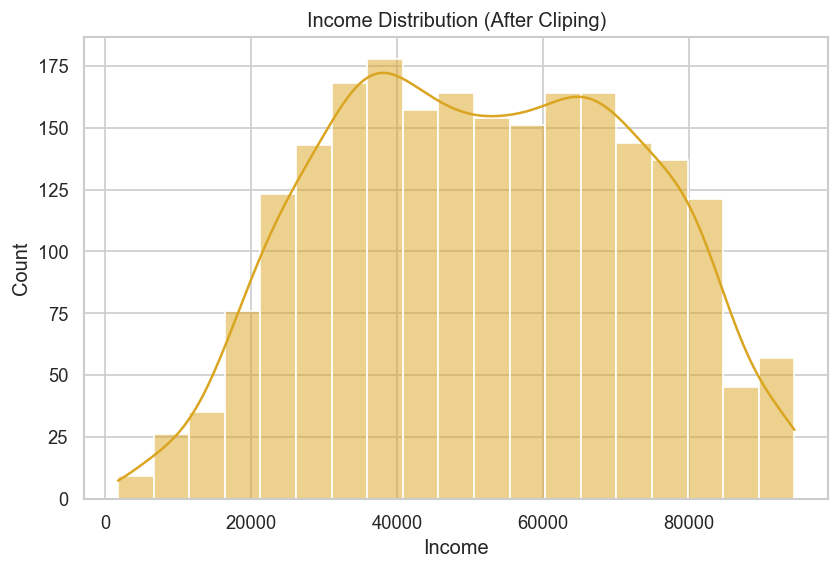

In [24]:
#Check Income after cliping 

df_income = df_prep[df_prep['Income'] < 200000]

plt.figure(figsize=(8, 5))
sns.histplot(df_income['Income'], kde=True, color='goldenrod')
plt.title('Income Distribution (After Cliping)')
plt.show()

In [25]:
#Check Missing values in income

print(df_prep['Income'].isnull().sum()[df_prep['Income'].isnull().sum() > 0])

[24]


In [26]:
# Calculate the median income for each education level

df_prep['Income'] = df_prep['Income'].fillna(df_prep.groupby('Education')['Income'].transform('median'))

In [27]:
#Check Missing values in income after imputation 

print(df_prep['Income'].isnull().sum()[df_prep['Income'].isnull().sum() > 0])

[]


#### Education Variable 

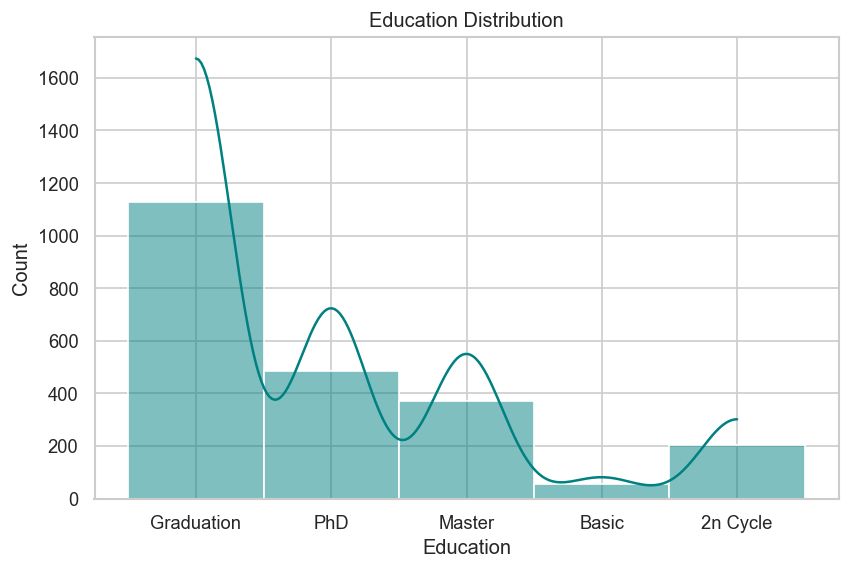

In [28]:
#Check Education

plt.figure(figsize=(8, 5))
sns.histplot(df_prep['Education'], kde=True, color='teal')
plt.title('Education Distribution')
plt.show()

#### Year_Birth

In [29]:
display(df_prep['Year_Birth'].describe())

count    2240.000000
mean     1968.805804
std        11.984069
min      1893.000000
25%      1959.000000
50%      1970.000000
75%      1977.000000
max      1996.000000
Name: Year_Birth, dtype: float64

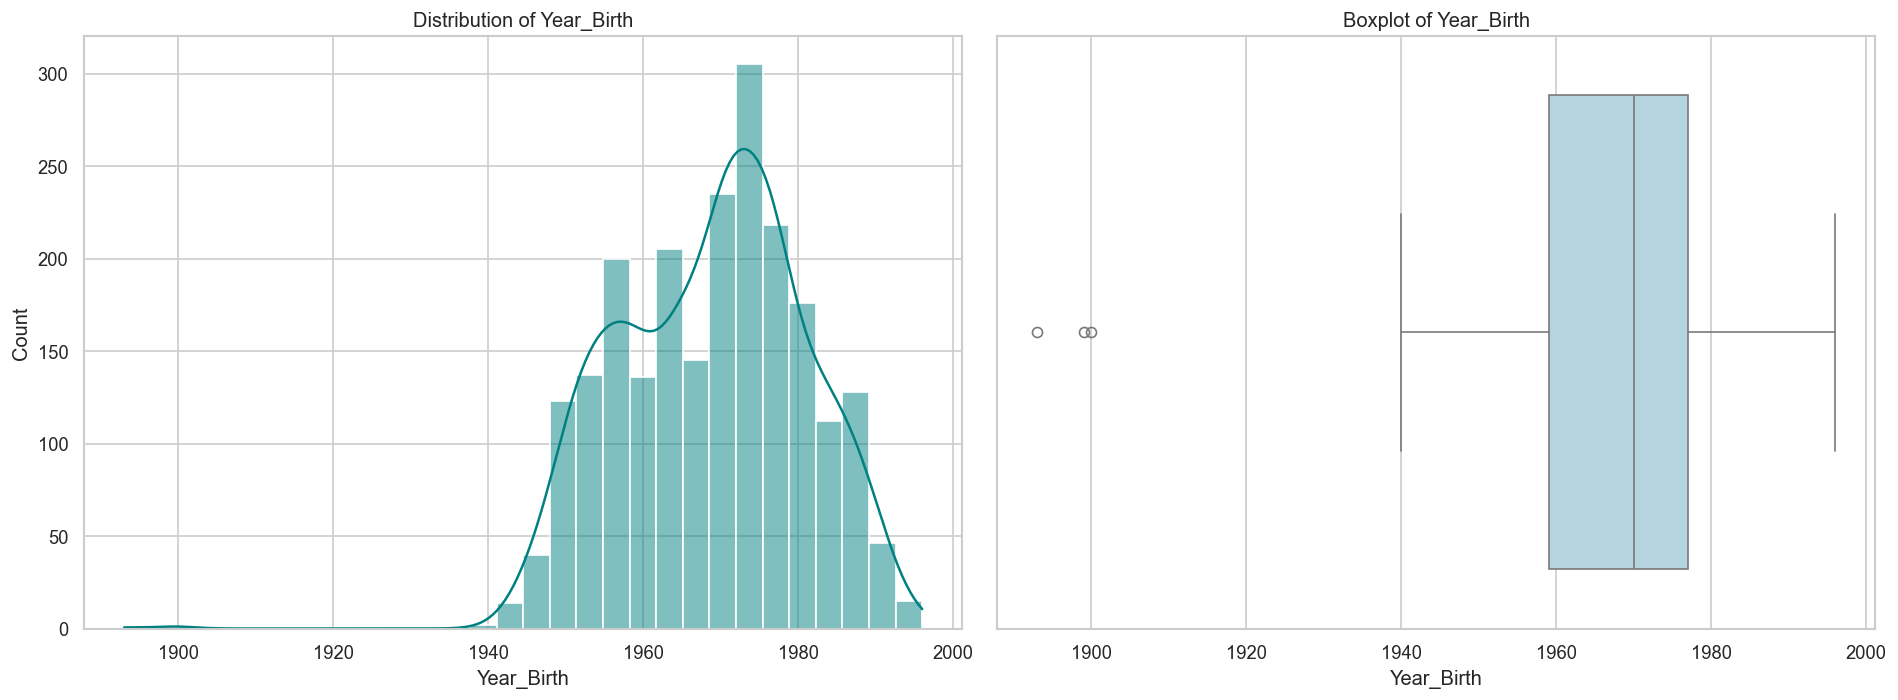

In [30]:
#Check Year of birth 

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

#Histogram: 
sns.histplot(df_prep['Year_Birth'], bins=30, kde=True, ax=axes[0], color='teal')
axes[0].set_title('Distribution of Year_Birth')

#Boxplot
sns.boxplot(x=df_prep['Year_Birth'], ax=axes[1], color='lightblue')
axes[1].set_title('Boxplot of Year_Birth')

plt.tight_layout()
plt.show()


In [31]:
#Check last enrollment in the database
#Convert to datetime format first
df_prep['Dt_Customer'] = pd.to_datetime(df_prep['Dt_Customer'])

#Find the most "recent" enrollment date in the DB
last_enrollment = df_prep['Dt_Customer'].max()
print(f"The last customer enrolled on: {last_enrollment}")

#Find the ID of that customer
last_cust = df_prep[df_prep['Dt_Customer'] == last_enrollment]['ID'].values
print(f"Customer ID(s) for this enrollment: {last_cust}")


The last customer enrolled on: 2042-11-09 00:00:00
Customer ID(s) for this enrollment: [9909]


Observations: 
Some kind of error in the dataset, since the last customer enter in the future (2042). Probably a miss spelling error or some kind of typo. 

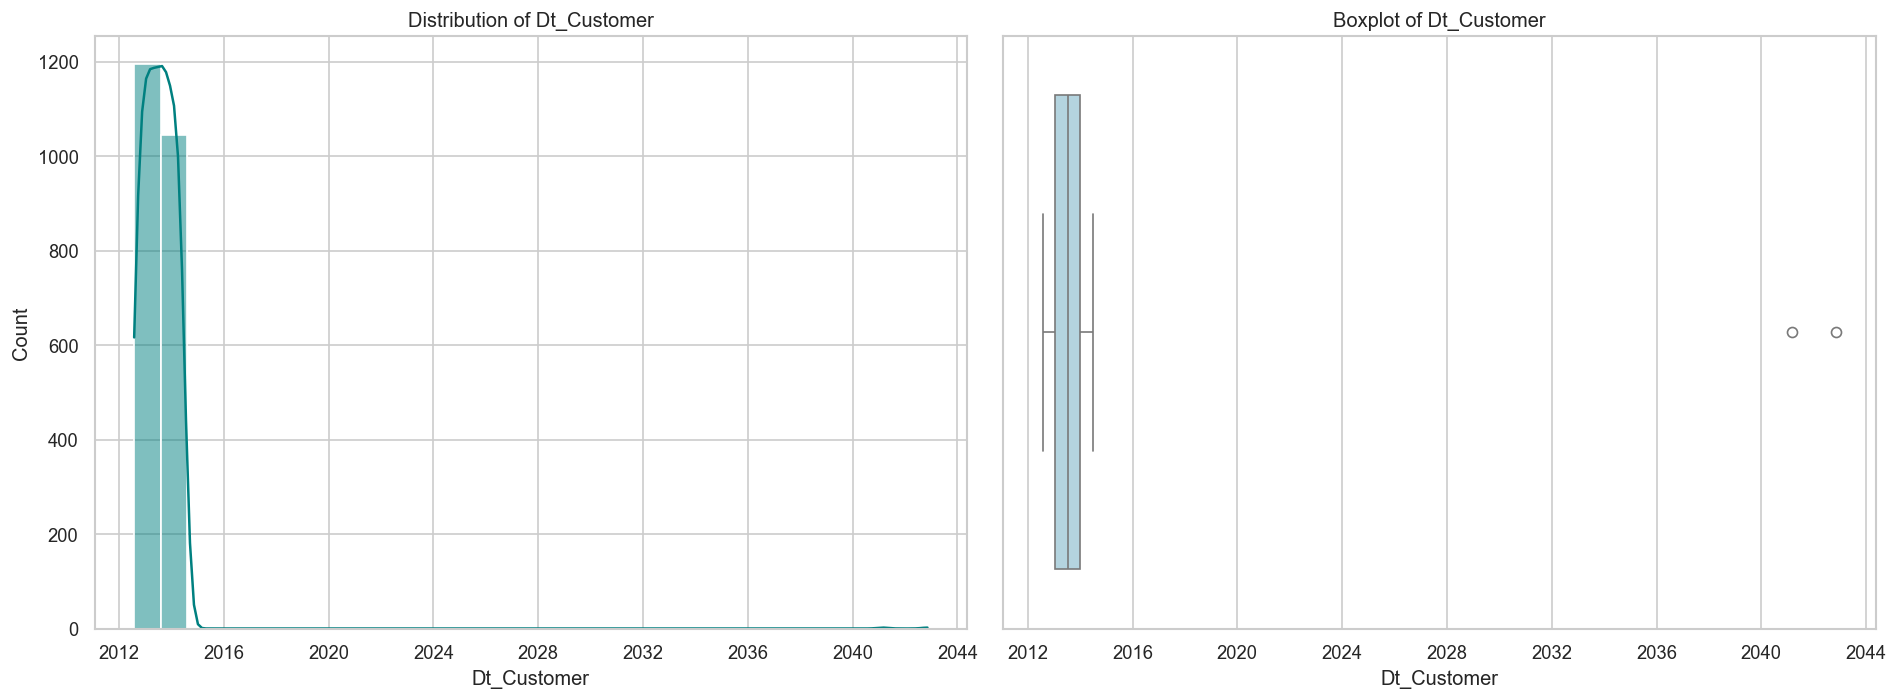

In [32]:
#Check last enrollment in the database

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

#Histogram: 
sns.histplot(df_prep['Dt_Customer'], bins=30, kde=True, ax=axes[0], color='teal')
axes[0].set_title('Distribution of Dt_Customer')

#Boxplot
sns.boxplot(x=df_prep['Dt_Customer'], ax=axes[1], color='lightblue')
axes[1].set_title('Boxplot of Dt_Customer')

plt.tight_layout()
plt.show()


In [33]:
display(df_prep['Dt_Customer'].describe())

count                             2240
mean     2013-07-19 17:05:21.428571392
min                2012-07-30 00:00:00
25%                2013-01-16 18:00:00
50%                2013-07-09 00:00:00
75%                2013-12-31 00:00:00
max                2042-11-09 00:00:00
Name: Dt_Customer, dtype: object

In [34]:
#Check Dt_Customer Outliers 

customer_99 = df_prep['Dt_Customer'].quantile(0.99)
print(f"Dt_Customer 99th percentile: {customer_99}")

Dt_Customer 99th percentile: 2014-06-22 14:38:24


In [35]:
#Check maximum value 
print(f"Latest enrollment in dataset: {df_prep['Dt_Customer'].max()}")

Latest enrollment in dataset: 2042-11-09 00:00:00


In [36]:
#Identify the specific rows that are over 2026

outliers = df_prep[df_prep['Dt_Customer'] > '2016-01-01']
print("\nRows with future enrollment dates:")
print(outliers[['ID', 'Dt_Customer']])


Rows with future enrollment dates:
      ID Dt_Customer
46  9909  2042-11-09
84   535  2041-02-25


In [37]:
#Identify the last realistic date 

last_realistic_date = df_prep[df_prep['Dt_Customer'] < '2016-01-01']['Dt_Customer'].max()
print(f"The last realistic enrollment date is: {last_realistic_date}")

The last realistic enrollment date is: 2014-06-29 00:00:00


In [38]:
#Caping the future values 
df_prep.loc[df_prep['Dt_Customer'] > last_realistic_date, 'Dt_Customer'] = last_realistic_date

In [39]:
#Check fix
print(f"New maximum date in dataset: {df_prep['Dt_Customer'].max()}")

New maximum date in dataset: 2014-06-29 00:00:00


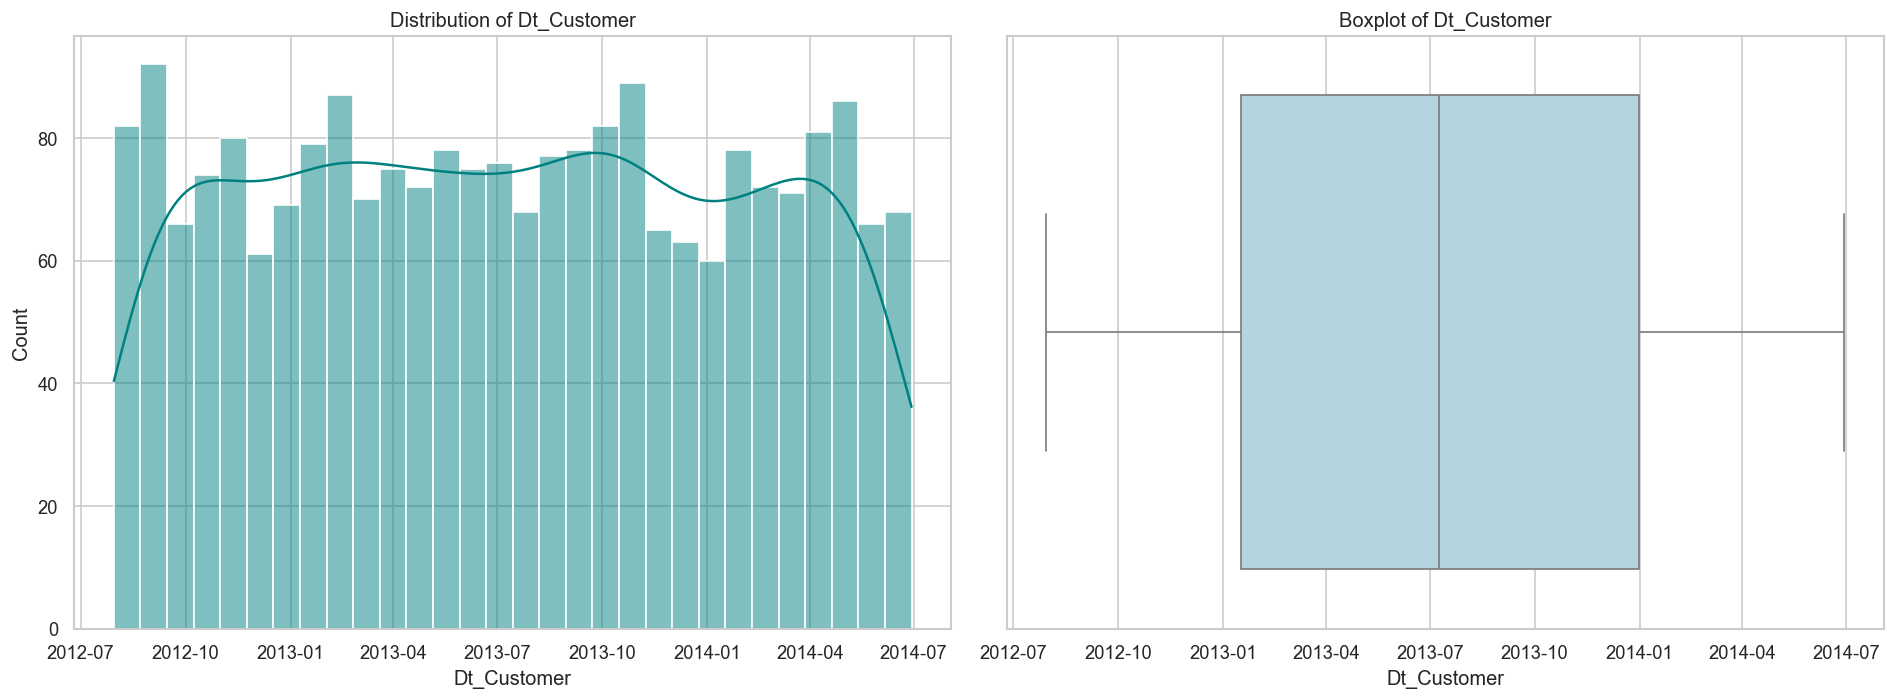

In [40]:
#Check last enrollment in the database after prep

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

#Histogram: 
sns.histplot(df_prep['Dt_Customer'], bins=30, kde=True, ax=axes[0], color='teal')
axes[0].set_title('Distribution of Dt_Customer')

#Boxplot
sns.boxplot(x=df_prep['Dt_Customer'], ax=axes[1], color='lightblue')
axes[1].set_title('Boxplot of Dt_Customer')

plt.tight_layout()
plt.show()


In [41]:
#Now, Convert Date to "Days as Customer"
reference_date = df_prep['Dt_Customer'].max() 
df_prep['Seniority'] = (reference_date - df_prep['Dt_Customer']).dt.days

In [42]:
# NOW you can use your numeric percentile code
seniority_99 = df_prep['Seniority'].quantile(0.99)
print(f'Seniority 99th percentile: {seniority_99:,.0f} days')

Seniority 99th percentile: 691 days


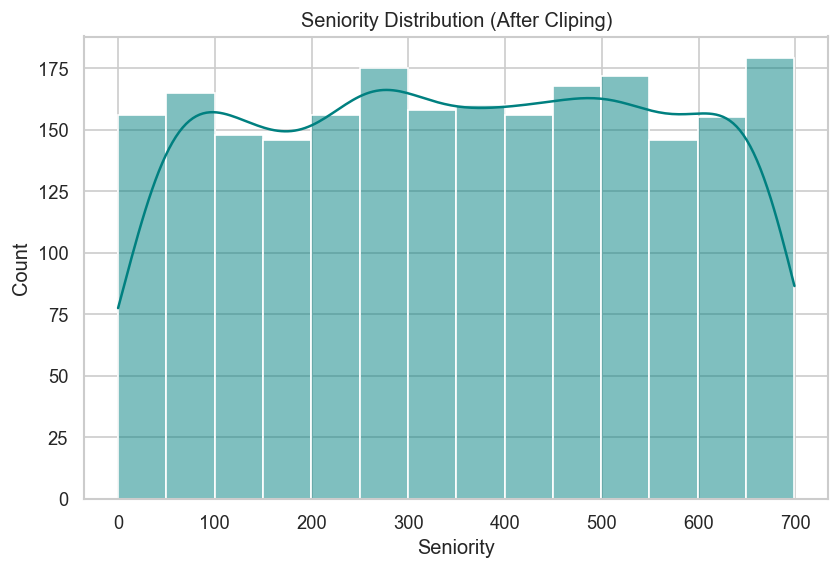

In [43]:
#Check Seniority 

plt.figure(figsize=(8, 5))
sns.histplot(df_prep['Seniority'], kde=True, color='teal')
plt.title('Seniority Distribution (After Cliping)')
plt.show()

In [44]:
display(df_prep['Seniority'].describe())

count    2240.000000
mean      353.260268
std       202.274756
min         0.000000
25%       180.000000
50%       355.000000
75%       528.250000
max       699.000000
Name: Seniority, dtype: float64

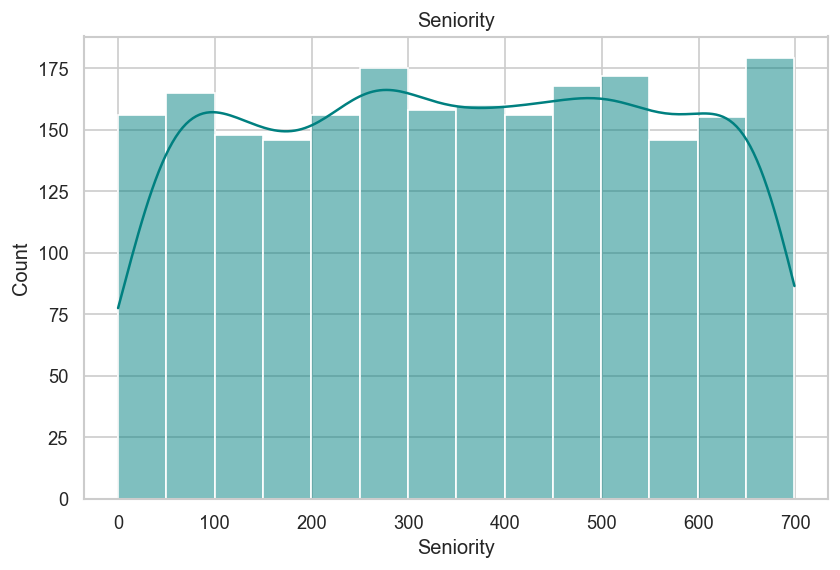

In [45]:
#Check Seniority after change 

plt.figure(figsize=(8, 5))
sns.histplot(df_prep['Seniority'], kde=True, color='teal')
plt.title('Seniority')
plt.show()

Observations: 
+ After checking and changing the last customer in the dataset (2014-06-29), this date passed to be a seniority in days. 
+ Next, the Age of the customers will be updated according to the last year in the database and not the actual year we are in. 

In [46]:
#Create Age variable
df_prep['Age'] = 2014 - df_prep['Year_Birth']

In [47]:
#Drop the original Year_Birth column and replace by age 
df_prep.drop(columns=['Year_Birth'], inplace=True)

#Check the results
print(df_prep['Age'].describe())

count    2240.000000
mean       45.194196
std        11.984069
min        18.000000
25%        37.000000
50%        44.000000
75%        55.000000
max       121.000000
Name: Age, dtype: float64


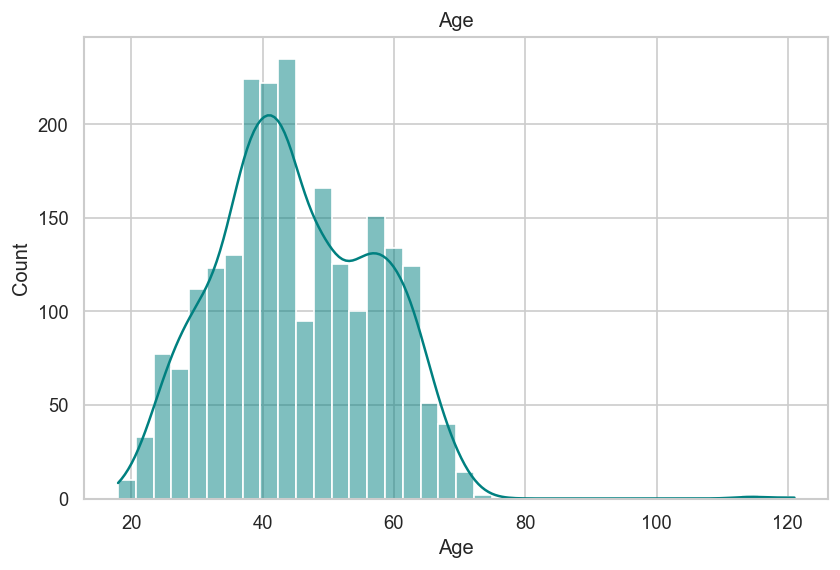

In [48]:
#Check Age 

plt.figure(figsize=(8, 5))
sns.histplot(df_prep['Age'], kde=True, color='teal')
plt.title('Age')
plt.show()

#### Marital_Status

In [49]:
#Check Marital Status Values 
print('Marital_Status value counts:')
print(df_prep['Marital_Status'].value_counts())

Marital_Status value counts:
Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64


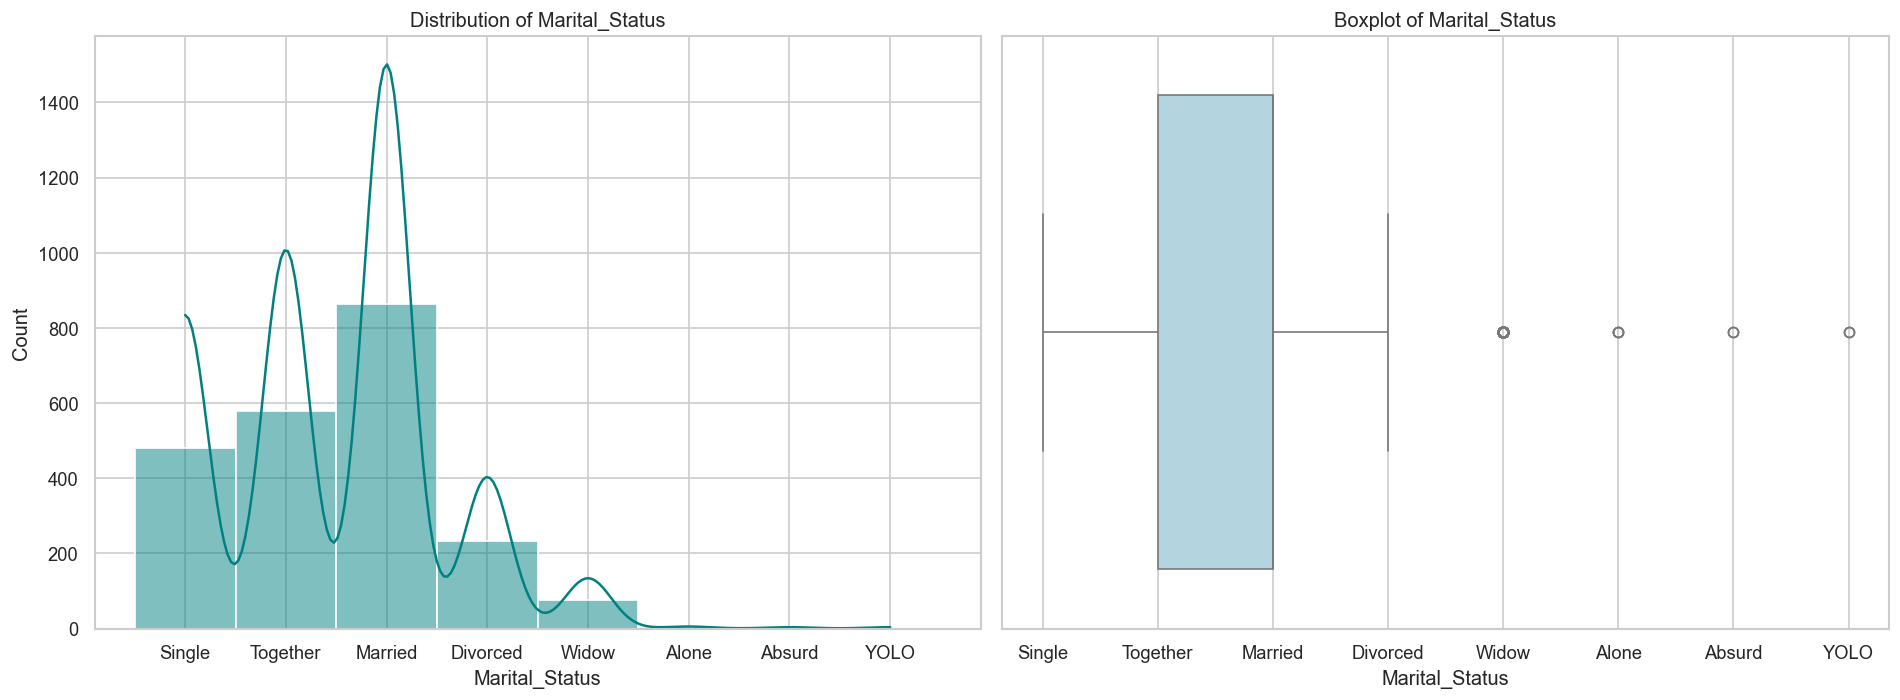

In [50]:
#Check Marital Status

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

#Histogram: 
sns.histplot(df_prep['Marital_Status'], bins=30, kde=True, ax=axes[0], color='teal')
axes[0].set_title('Distribution of Marital_Status')

#Boxplot
sns.boxplot(x=df_prep['Marital_Status'], ax=axes[1], color='lightblue')
axes[1].set_title('Boxplot of Marital_Status')

plt.tight_layout()
plt.show()


In [51]:
#Replace alone categories in Marital_Status to single 
df_prep['Marital_Status'] = df_prep['Marital_Status'].replace(['Absurd', 'YOLO', 'Alone'], 'Single')

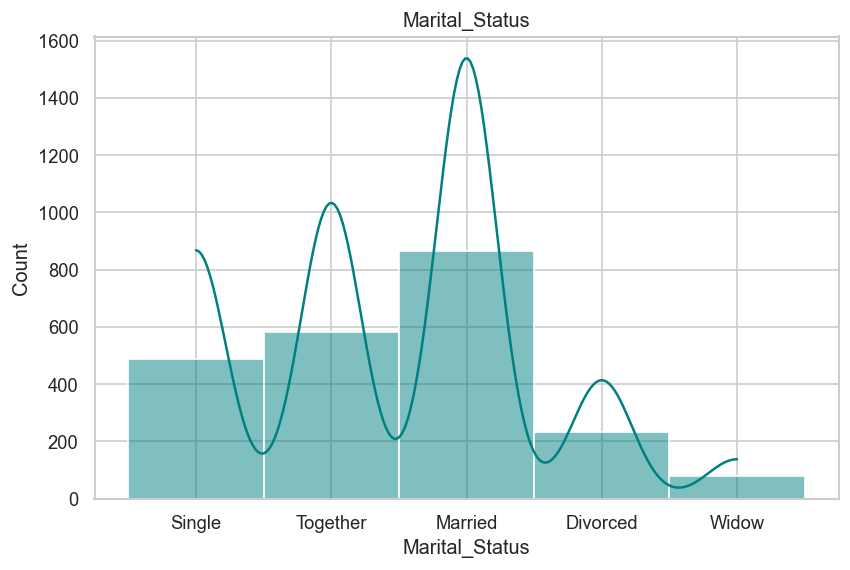

In [52]:
#Check Marital_Status after change 

plt.figure(figsize=(8, 5))
sns.histplot(df_prep['Marital_Status'], kde=True, color='teal')
plt.title('Marital_Status')
plt.show()

#### MntGoldProds Variable 

In [53]:
display(df_prep['MntGoldProds'].describe())

count    2187.000000
mean       44.341180
std        51.362621
min         0.000000
25%         9.000000
50%        25.000000
75%        57.000000
max       227.280000
Name: MntGoldProds, dtype: float64

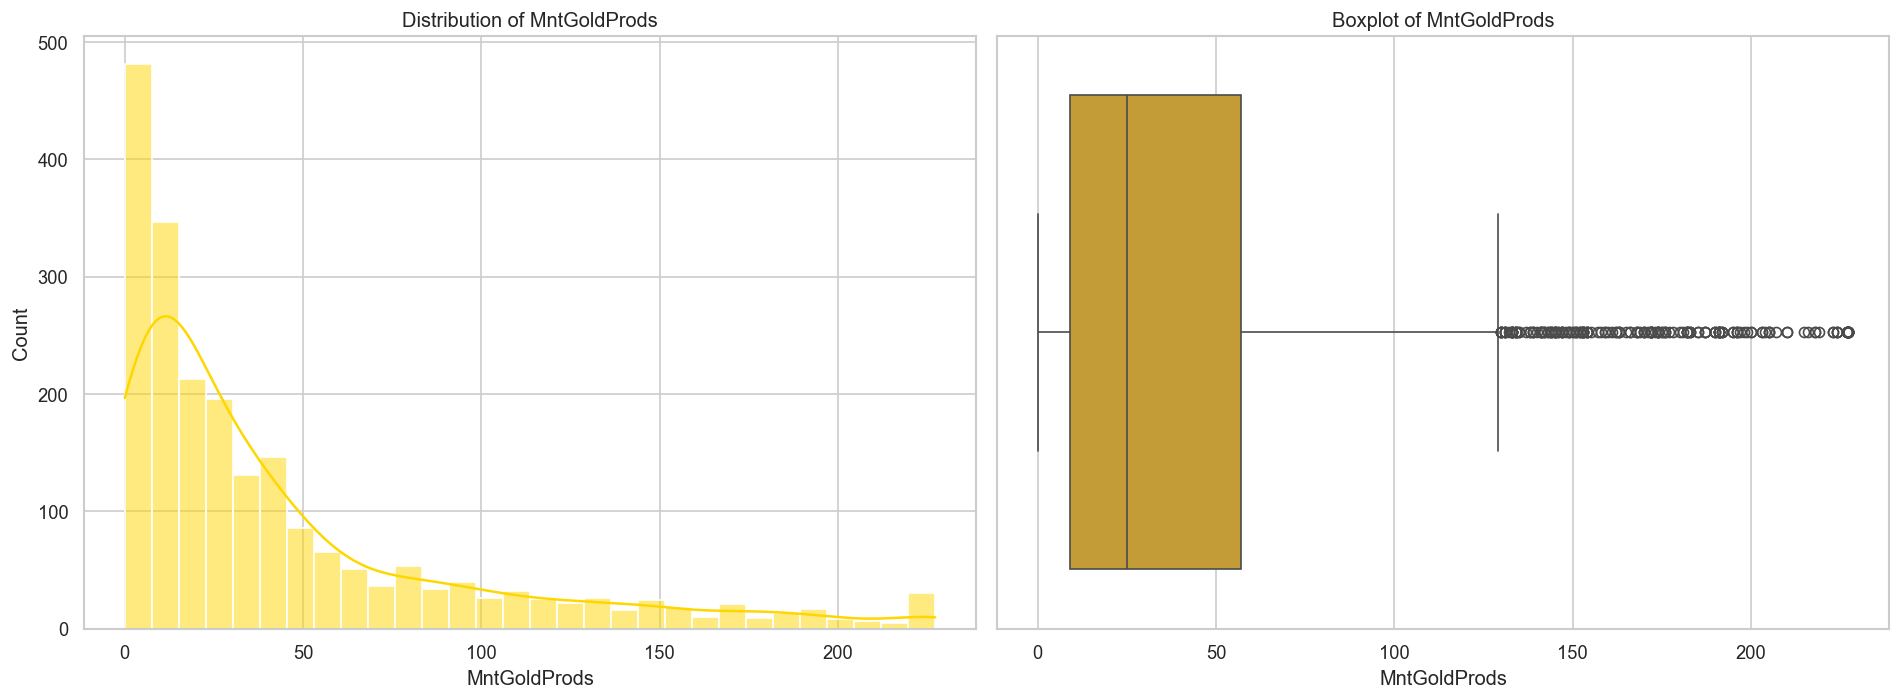

In [54]:
#Check MntGoldProds

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

#Histogram: 
sns.histplot(df_prep['MntGoldProds'], bins=30, kde=True, ax=axes[0], color='gold')
axes[0].set_title('Distribution of MntGoldProds')

#Boxplot
sns.boxplot(x=df_prep['MntGoldProds'], ax=axes[1], color='goldenrod')
axes[1].set_title('Boxplot of MntGoldProds')

plt.tight_layout()
plt.show()


In [55]:
#Calculate IQR
Q1 = df_prep['MntGoldProds'].quantile(0.25)
Q3 = df_prep['MntGoldProds'].quantile(0.75)
IQR = Q3 - Q1

#Define bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

#Identify and count outliers
outliers = df_prep[(df_prep['MntGoldProds'] < lower_bound) | (df_prep['MntGoldProds'] > upper_bound)]
print(f"Number of outliers in MntGoldProds: {len(outliers)}")
print(f"Percentage of outliers: {len(outliers)/len(df_prep)*100:.2f}%")

Number of outliers in MntGoldProds: 200
Percentage of outliers: 8.93%


In [56]:
#Calculate 95th percentile
cap_value = df_prep['MntGoldProds'].quantile(0.95)

#Apply the cap above the 95th percentile
df_prep['MntGoldProds'] = df_prep['MntGoldProds'].clip(upper=cap_value)

print(f"Values in MntGoldProds capped at: {cap_value}")

Values in MntGoldProds capped at: 166.0


In [57]:
#Check Missing values in MntGoldProds 

print(df_prep.isnull().sum()[df_prep.isnull().sum() > 0])

MntGoldProds    53
dtype: int64


In [58]:
#Numeric features to predict gold spending (Income, MntWines, and other spending categories) using KNN

impute_cols = ['Income', 'MntWines', 'MntMeatProducts', 'MntFishProducts', 'MntGoldProds']

In [59]:
from sklearn.impute import KNNImputer

#Initiate the KNN Imputer (K=5 is standard)
knn_imputer = KNNImputer(n_neighbors=5)

#Do imputation
df_prep[impute_cols] = knn_imputer.fit_transform(df_prep[impute_cols])

print("Missing values in MntGoldProds after KNN:", df_prep['MntGoldProds'].isnull().sum())

Missing values in MntGoldProds after KNN: 0


In [60]:
#Check Missing values in MntGoldProds after KNN

print(df_prep.isnull().sum()[df_prep.isnull().sum() > 0])

Series([], dtype: int64)


In [61]:
display(df_prep['MntGoldProds'].describe())

count    2240.000000
mean       42.350625
std        46.235386
min         0.000000
25%         9.000000
50%        25.000000
75%        56.000000
max       166.000000
Name: MntGoldProds, dtype: float64

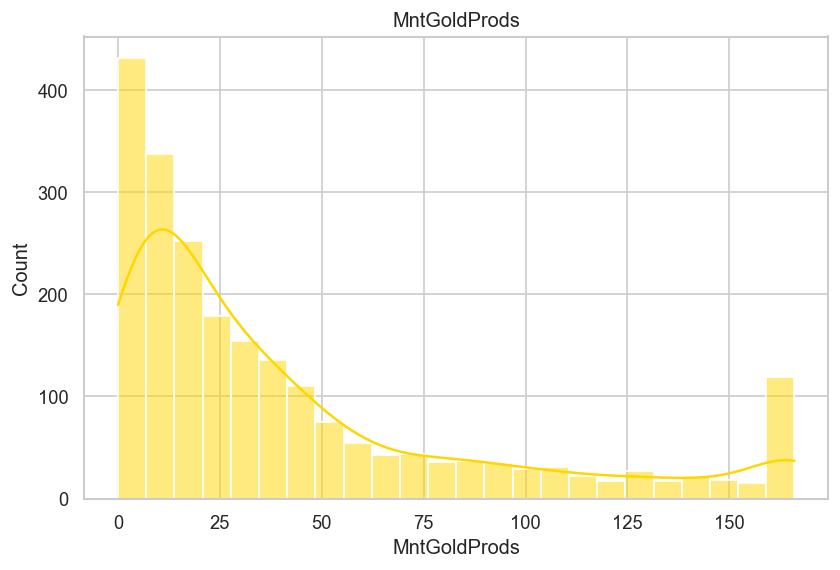

In [62]:
#Check MntGoldProds after change 

plt.figure(figsize=(8, 5))
sns.histplot(df_prep['MntGoldProds'], kde=True, color='gold')
plt.title('MntGoldProds')
plt.show()

### Drop Columns

In [63]:
# Check Z columns constancy 
print("Nunique for Z columns:\n", df_prep[['Z_CostContact', 'Z_Revenue']].nunique())

print("\nValue counts for Z_CostContact:")
print(df_prep['Z_CostContact'].value_counts())

print("\nValue counts for Z_Revenue:")
print(df_prep['Z_Revenue'].value_counts())

Nunique for Z columns:
 Z_CostContact    1
Z_Revenue        1
dtype: int64

Value counts for Z_CostContact:
Z_CostContact
3    2240
Name: count, dtype: int64

Value counts for Z_Revenue:
Z_Revenue
11    2240
Name: count, dtype: int64


In [64]:
#Drop Columns 

df_prep.drop(columns=['ID', 'Z_CostContact', 'Z_Revenue', 'Dt_Customer'], inplace=True)
print(f'Shape after dropping: {df_prep.shape}')

Shape after dropping: (2240, 26)


### Feature Engineering 

In [65]:
#Sum of all product Spending 

spend_cols = ['MntWines', 'MntFruits', 'MntMeatProducts',
              'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
df_prep['TotalSpent'] = df_prep[spend_cols].sum(axis=1)

In [66]:
#Total Accepted 

accepted_cols = ['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3',
                 'AcceptedCmp4', 'AcceptedCmp5']
df_prep['TotalAccepted'] = df_prep[accepted_cols].sum(axis=1)

In [67]:
# Total Children 
df_prep['Total_Children'] = df_prep['Kidhome'] + df_prep['Teenhome']

In [68]:
print(f'Shape after feature engineering: {df_prep.shape}')
df_prep[['Age', 'TotalSpent', 'TotalAccepted', 'Total_Children']].describe()

Shape after feature engineering: (2240, 29)


,Age,TotalSpent,TotalAccepted,Total_Children
count,2240.000000,2.240000e+03,2240.000000,2240.000000
mean,45.194196,1.221088e+04,0.297768,0.950446
std,11.984069,4.973984e+05,0.678381,0.751803
min,18.000000,5.000000e+00,0.000000,0.000000
25%,37.000000,6.900000e+01,0.000000,0.000000
50%,44.000000,3.960000e+02,0.000000,1.000000
75%,55.000000,1.045500e+03,0.000000,1.000000
max,121.000000,2.342483e+07,4.000000,3.000000


### Encode Categorical Variables 

In [69]:
#Check before encode Marital Status 

print('Marital_Status value counts:')
print(df_prep['Marital_Status'].value_counts())

Marital_Status value counts:
Marital_Status
Married     864
Together    580
Single      487
Divorced    232
Widow        77
Name: count, dtype: int64


In [70]:
#Check before encode Education

print('Education value counts:')
print(df_prep['Education'].value_counts())

Education value counts:
Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64


In [71]:
# One-hot encode with k-1 dummies (drop_first=True)
df_prep = pd.get_dummies(df_prep, columns=['Education', 'Marital_Status'], drop_first=True)
print(f'Shape after encoding: {df_prep.shape}')
df_prep.head(2)

Shape after encoding: (2240, 35)


,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,TotalAccepted,Total_Children,Education_Basic,Education_Graduation,Education_Master,Education_PhD,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow
0,58138.0,0,0,58,635.0,88.0,546.0,172.0,88,88.0,...,0,0,False,True,False,False,False,True,False,False
1,46344.0,1,1,38,11.0,1.0,6.0,2.0,1,6.0,...,0,2,False,True,False,False,False,True,False,False


### Check Response Variable (Class balance)

Target distribution:
Response
0    1906
1     334
Name: count, dtype: int64

Class imbalance ratio: 5.7:1 (No:Yes)


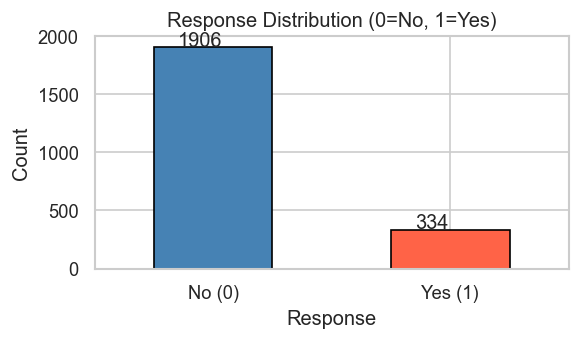

In [72]:
#Class Balance Target variable Response 

print('Target distribution:')
counts = df_prep['Response'].value_counts()
print(counts)
print(f'\nClass imbalance ratio: {counts[0]/counts[1]:.1f}:1 (No:Yes)')

fig, ax = plt.subplots(figsize=(5,3))
counts.plot(kind='bar', ax=ax, color=['steelblue', 'tomato'], edgecolor='black')
ax.set_title('Response Distribution (0=No, 1=Yes)')
ax.set_xlabel('Response')
ax.set_ylabel('Count')
ax.set_xticklabels(['No (0)', 'Yes (1)'], rotation=0)
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x()+0.1, p.get_height()+10))
plt.tight_layout()
plt.show()

### Train and Test

In [73]:
# Drop the target 
TARGET = 'Response'
X = df_prep.drop(columns=[TARGET])
y = df_prep[TARGET]

# Split data (20/80)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f'Train size : {X_train.shape[0]} rows')
print(f'Test size  : {X_test.shape[0]} rows')
print(f'Train Response distribution:\n{y_train.value_counts(normalize=True).round(3)}')
print(f'Test Response distribution:\n{y_test.value_counts(normalize=True).round(3)}')

Train size : 1792 rows
Test size  : 448 rows
Train Response distribution:
Response
0    0.851
1    0.149
Name: proportion, dtype: float64
Test Response distribution:
Response
0    0.85
1    0.15
Name: proportion, dtype: float64


## Modeling 

In [74]:
#Explore max_depth and undertand bias-variance

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

depths      = [1, 2, 3, 4, 5, 6, 7, 8, None]   
cv_auc_mean = []
cv_auc_std  = []
train_auc   = []

for depth in depths:
    dt = DecisionTreeClassifier(
        max_depth=depth,
        class_weight='balanced',
        random_state=RANDOM_STATE
    )
    cv_scores = cross_val_score(dt, X_train, y_train, cv=cv, scoring='roc_auc')
    dt.fit(X_train, y_train)
    tr_auc = roc_auc_score(y_train, dt.predict_proba(X_train)[:, 1])
    cv_auc_mean.append(cv_scores.mean())
    cv_auc_std.append(cv_scores.std())
    train_auc.append(tr_auc)

depth_labels = [str(d) for d in depths[:-1]] + ['None\n(full)']

In [75]:
#Check depths

print(f'{"Depth":>8}  {"Train AUC":>10}  {"CV AUC":>10}  {"Std":>8}  {"Gap":>8}  {"Status":}')
print('-' * 70)
for d, tr, cv_m, cv_s in zip(depth_labels, train_auc, cv_auc_mean, cv_auc_std):
    gap = tr - cv_m

    if cv_m < 0.72 and tr < 0.75:          
        flag = '  underfit'
    elif gap > 0.10:                        
        flag = '  overfit'
    else:
        flag = '  good'

    print(f'{d:>8}  {tr:>10.4f}  {cv_m:>10.4f}  {cv_s:>8.4f}  {gap:>8.4f}{flag}')

   Depth   Train AUC      CV AUC       Std       Gap  Status
----------------------------------------------------------------------
       1      0.7116      0.7116    0.0217    0.0000  underfit
       2      0.7813      0.7687    0.0112    0.0126  good
       3      0.8410      0.7901    0.0153    0.0509  good
       4      0.8775      0.7671    0.0250    0.1105  overfit
       5      0.9079      0.7553    0.0398    0.1526  overfit
       6      0.9338      0.7239    0.0532    0.2098  overfit
       7      0.9551      0.6872    0.0679    0.2679  overfit
       8      0.9685      0.7058    0.0444    0.2627  overfit
None
(full)      0.9999      0.6686    0.0416    0.3313  overfit


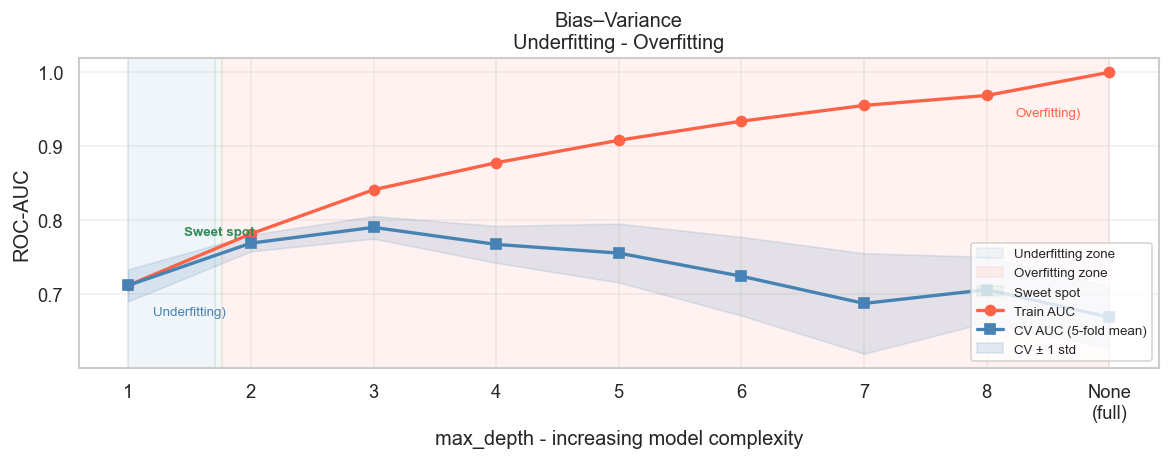

In [76]:
#Visualize 

x_pos = list(range(len(depths)))

fig, ax = plt.subplots(figsize=(10, 4))

underfit_end = 0.7116   #CV AUC
overfit_start = 0.7671  

ax.axvspan(0, underfit_end,    alpha=0.08, color='steelblue', label='Underfitting zone')
ax.axvspan(overfit_start, len(depths)-1, alpha=0.08, color='tomato',    label='Overfitting zone')
ax.axvspan(underfit_end, overfit_start,  alpha=0.06, color='seagreen',  label='Sweet spot')

ax.plot(x_pos, train_auc,   'o-', color='tomato',    lw=2, ms=6, label='Train AUC')
ax.plot(x_pos, cv_auc_mean, 's-', color='steelblue', lw=2, ms=6, label='CV AUC (5-fold mean)')
ax.fill_between(
    x_pos,
    [m - s for m, s in zip(cv_auc_mean, cv_auc_std)],
    [m + s for m, s in zip(cv_auc_mean, cv_auc_std)],
    alpha=0.15, color='steelblue', label='CV ± 1 std'
)

#Annotations

ax.annotate('Underfitting)',
            xy=(0.5, min(cv_auc_mean[:2])),
            xytext=(0.5, min(cv_auc_mean[:2]) - 0.04),
            ha='center', fontsize=8, color='steelblue')

ax.annotate('Overfitting)',
            xy=(len(depths)-1.5, max(train_auc[-2:])),
            xytext=(len(depths)-1.5, max(train_auc[-2:]) - 0.06),
            ha='center', fontsize=8, color='tomato')

ax.annotate('Sweet spot',
            xy=((underfit_end + overfit_start) / 2, max(cv_auc_mean) - 0.01),
            ha='center', fontsize=8, color='seagreen', fontweight='bold')

ax.set_xticks(x_pos)
ax.set_xticklabels(depth_labels)
ax.set_xlabel('max_depth - increasing model complexity')
ax.set_ylabel('ROC-AUC')
ax.set_title('Bias–Variance\n'
             'Underfitting - Overfitting')
ax.legend(loc='lower right', fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Observations:
+ Depth 1 - underfit: tree too simple, misses patterns (high bias)
+ Depth 3–5 - sweet spot: CV AUC peaks, Train-CV gap is small
+ Depth 7+ - overfit: Train AUC climbs but CV AUC drops (high variance)
+ Depth=None - worst CV AUC despite - perfect train fit

### Hyperparameter Tuning 

In [77]:
#Parameters 
param_grid = {
    'max_depth'         : [1, 2, 3, 4, 5, 6, 7, 8],
    'min_samples_split' : [5, 8, 10, 15, 20, 25, 30, 50],
    'min_samples_leaf'  : [3, 5, 10, 15, 18, 20, 25, 30],
    'criterion'         : ['gini', 'entropy', 'log_loss']
}

dt_base = DecisionTreeClassifier(
    class_weight='balanced',
    random_state=RANDOM_STATE
)

grid_search = GridSearchCV(
    dt_base,
    param_grid,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=0
)
grid_search.fit(X_train, y_train)

print(f'Best hyperparameters : {grid_search.best_params_}')
print(f'Best CV AUC          : {grid_search.best_score_:.4f}')

Best hyperparameters : {'criterion': 'entropy', 'max_depth': 6, 'min_samples_leaf': 30, 'min_samples_split': 5}
Best CV AUC          : 0.8266


Observations: 

Depth sweep (default leaf settings):
  + depth=3 - stops splitting early - underfits slightly - CV ≈ 0.80
  + depth=6 - splits on tiny groups - overfits - CV drops


GridSearch (min_samples_leaf=30):
 + depth=6 - tries to go deeper but refuses splits, where either child would have < 30 samples
 + effectively the tree self-prunes
 + gets the benefit of depth without the overfitting
 + CV ≈ 0.83 - better than either alone

### Train - Final Model 

In [78]:
best_params = grid_search.best_params_

best_dt = DecisionTreeClassifier(
    **best_params,
    class_weight='balanced',
    random_state=RANDOM_STATE
)
best_dt.fit(X_train, y_train)

print(f'Tree depth (actual): {best_dt.get_depth()}')
print(f'Number of leaves: {best_dt.get_n_leaves()}')
print(f'Number of nodes: {best_dt.tree_.node_count}')

Tree depth (actual): 6
Number of leaves: 27
Number of nodes: 53


### Visualize Decision Tree 

In [79]:
# Text representation of the tree
print('Decision Tree — top 3 levels (text view):')
print('=' * 60)
tree_text = export_text(
    best_dt,
    feature_names=list(X_train.columns),
    max_depth=3
)
print(tree_text)

Decision Tree — top 3 levels (text view):
|--- TotalAccepted <= 0.50
|   |--- Seniority <= 390.50
|   |   |--- Recency <= 40.50
|   |   |   |--- NumCatalogPurchases <= 0.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- NumCatalogPurchases >  0.50
|   |   |   |   |--- truncated branch of depth 3
|   |   |--- Recency >  40.50
|   |   |   |--- MntSweetProducts <= 84.00
|   |   |   |   |--- class: 0
|   |   |   |--- MntSweetProducts >  84.00
|   |   |   |   |--- class: 0
|   |--- Seniority >  390.50
|   |   |--- TotalSpent <= 46.50
|   |   |   |--- MntWines <= 6.50
|   |   |   |   |--- class: 0
|   |   |   |--- MntWines >  6.50
|   |   |   |   |--- class: 0
|   |   |--- TotalSpent >  46.50
|   |   |   |--- Seniority <= 586.50
|   |   |   |   |--- truncated branch of depth 3
|   |   |   |--- Seniority >  586.50
|   |   |   |   |--- truncated branch of depth 3
|--- TotalAccepted >  0.50
|   |--- Recency <= 20.50
|   |   |--- Total_Children <= 0.50
|   |   |   |--- class: 

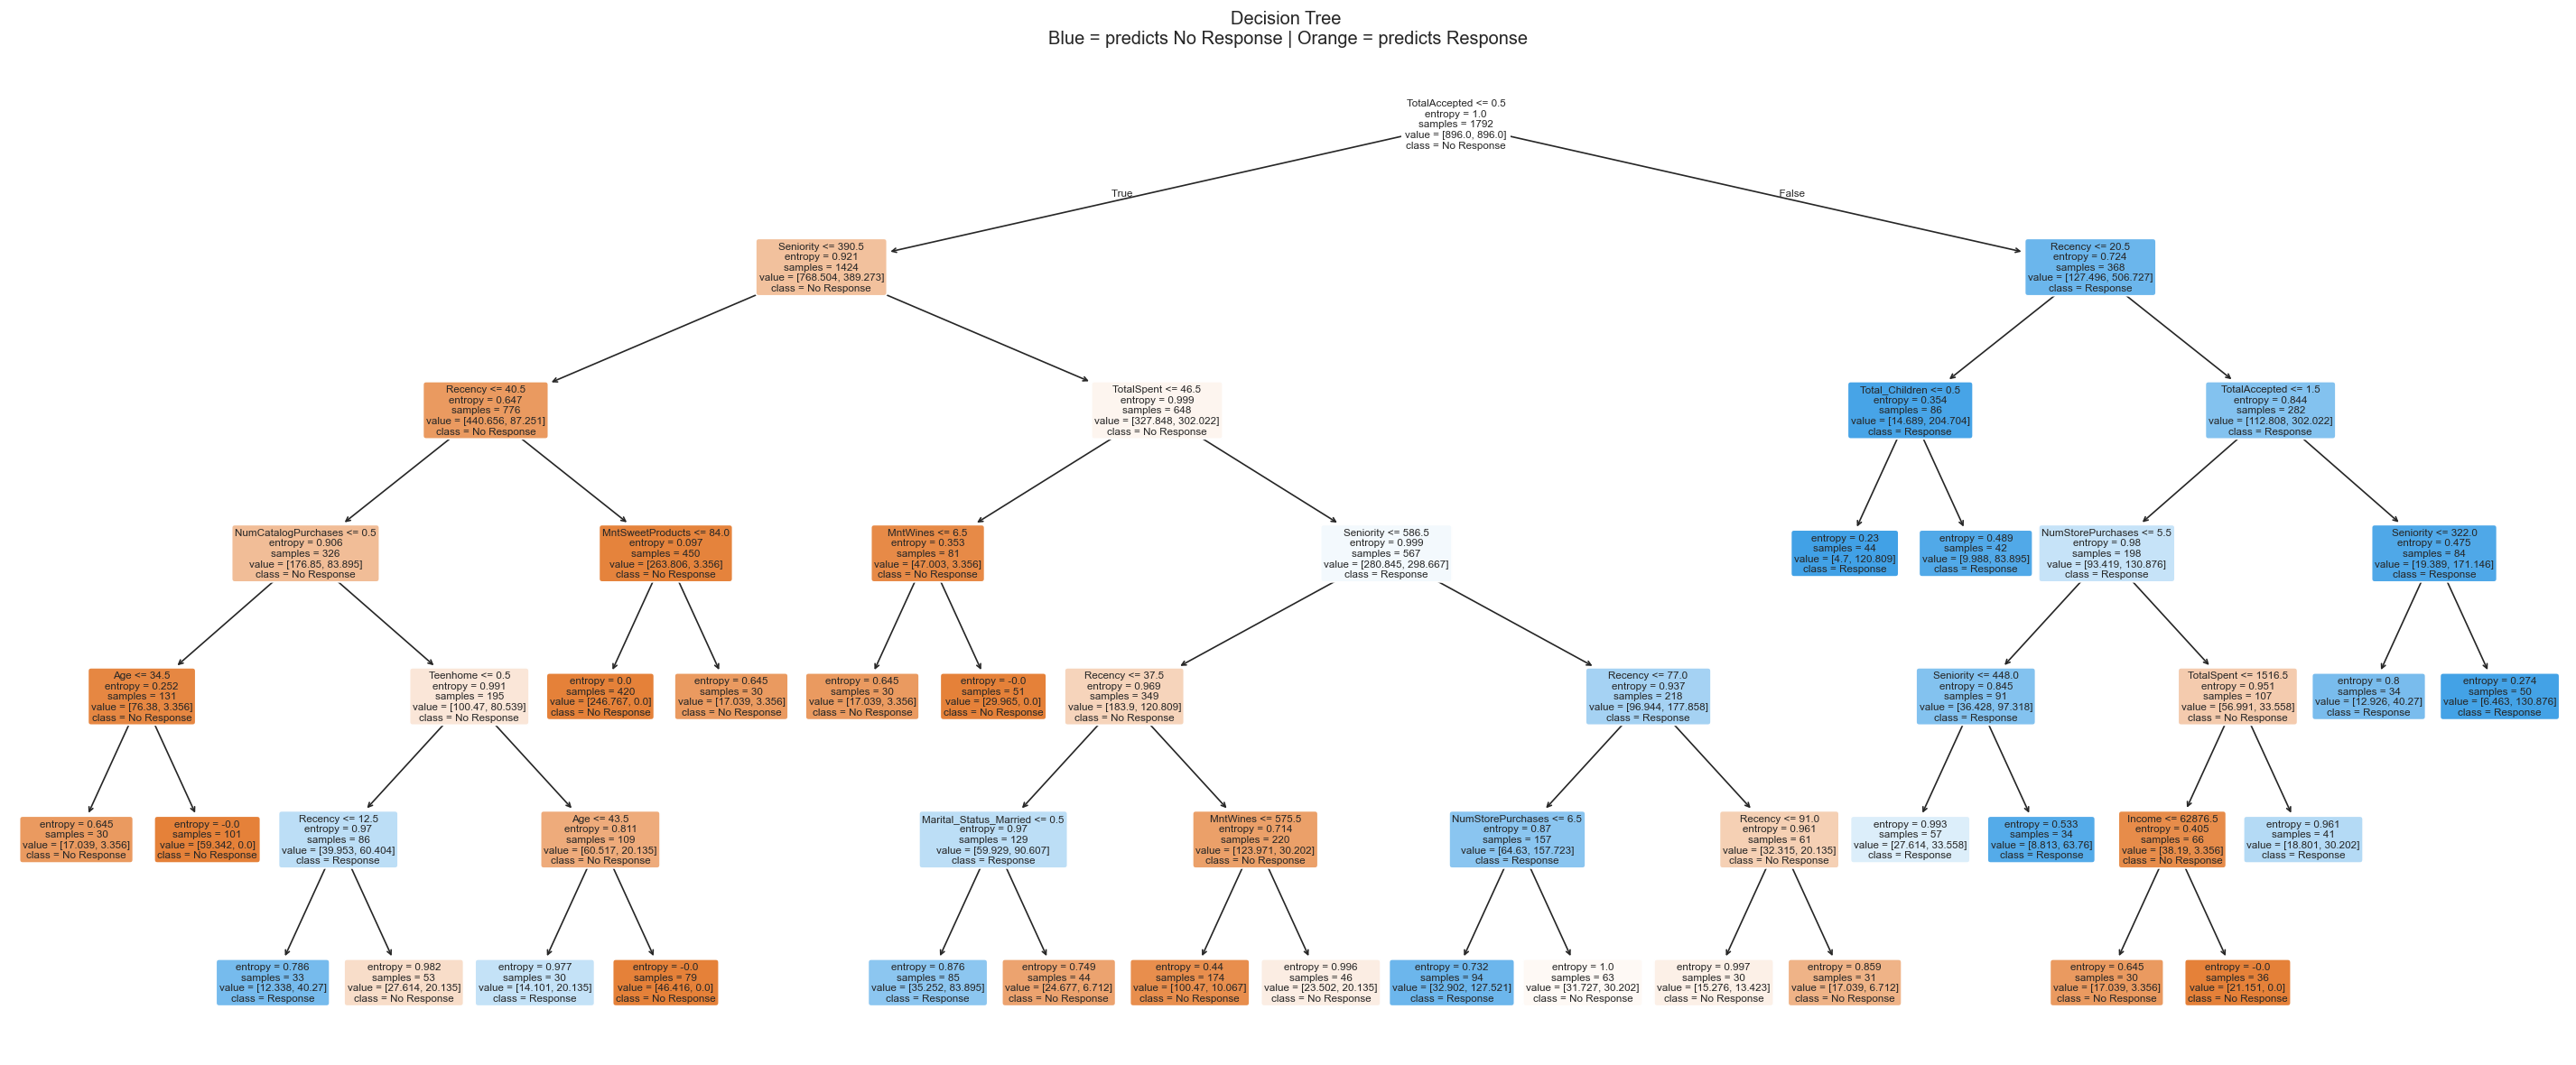

In [80]:
#View tree — capped depth 4 
fig, ax = plt.subplots(figsize=(24, 10))
plot_tree(
    best_dt,
    feature_names=X_train.columns.tolist(),
    class_names=['No Response', 'Response'],
    filled=True,
    rounded=True,
    max_depth=6,
    fontsize=7,
    ax=ax,
    impurity=True
)
ax.set_title('Decision Tree \n'
             'Blue = predicts No Response | Orange = predicts Response',
             fontsize=12)
plt.tight_layout()
plt.show()

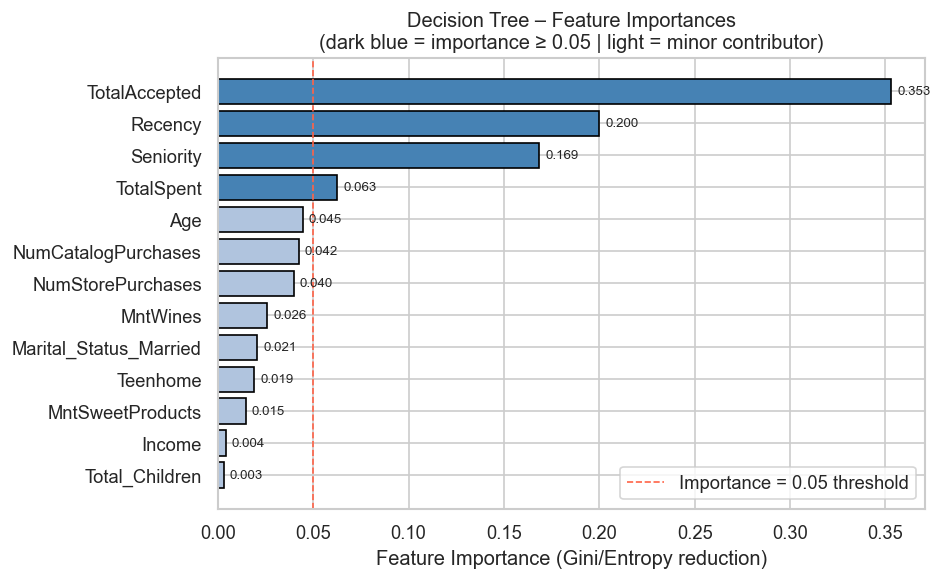

Top 5 features:
TotalAccepted    0.3530
Recency          0.2000
Seniority        0.1686
TotalSpent       0.0627
Age              0.0448
dtype: float64


In [81]:
#Feature Importance 

feat_imp = pd.Series(
    best_dt.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

feat_imp_nonzero = feat_imp[feat_imp > 0]

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['steelblue' if v >= 0.05 else 'lightsteelblue'
          for v in feat_imp_nonzero.values]
bars = ax.barh(
    feat_imp_nonzero.index[::-1],
    feat_imp_nonzero.values[::-1],
    color=colors[::-1],
    edgecolor='black'
)
for bar, val in zip(bars, feat_imp_nonzero.values[::-1]):
    ax.text(bar.get_width() + 0.003,
            bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', fontsize=8)

ax.axvline(0.05, color='tomato', linestyle='--', lw=1,
           label='Importance = 0.05 threshold')
ax.set_xlabel('Feature Importance (Gini/Entropy reduction)')
ax.set_title('Decision Tree – Feature Importances\n'
             '(dark blue = importance ≥ 0.05 | light = minor contributor)')
ax.legend()
plt.tight_layout()
plt.show()

print('Top 5 features:')
print(feat_imp.head(5).round(4))

## Evaluation

In [82]:
#Predictions on Test Set
y_pred       = best_dt.predict(X_test)
y_pred_proba = best_dt.predict_proba(X_test)[:, 1]  # P(Response = 1)

### Confusion Matrix and Core Metrics 

In [83]:
#Core Metrics 

print('=' * 54)
print('  EVALUATION METRICS – TEST SET')
print('=' * 54)
print(f'  Accuracy  : {accuracy_score(y_test, y_pred):.4f}')
print(f'  Precision : {precision_score(y_test, y_pred):.4f}')
print(f'  Recall    : {recall_score(y_test, y_pred):.4f}   - prioritised')
print(f'  F1-Score  : {f1_score(y_test, y_pred):.4f}')
print(f'  ROC-AUC   : {roc_auc_score(y_test, y_pred_proba):.4f}   - primary quality metric')
print()
print(classification_report(
    y_test, y_pred,
    target_names=['No Response (0)', 'Response (1)']
))

  EVALUATION METRICS – TEST SET
  Accuracy  : 0.7746
  Precision : 0.3672
  Recall    : 0.7015   - prioritised
  F1-Score  : 0.4821
  ROC-AUC   : 0.7916   - primary quality metric

                 precision    recall  f1-score   support

No Response (0)       0.94      0.79      0.86       381
   Response (1)       0.37      0.70      0.48        67

       accuracy                           0.77       448
      macro avg       0.65      0.74      0.67       448
   weighted avg       0.85      0.77      0.80       448



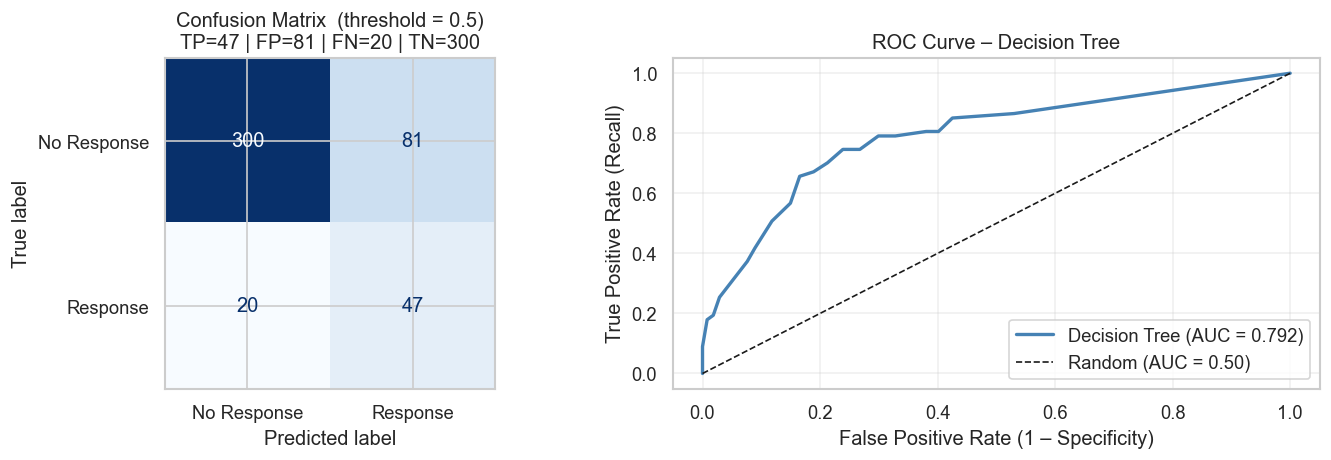

AUC = 0.7916  →  Satisfactory (≥ 0.7)


In [84]:
#Confusion matrix

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['No Response', 'Response']
)
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(
    f'Confusion Matrix  (threshold = 0.5)\n'
    f'TP={tp} | FP={fp} | FN={fn} | TN={tn}'
)

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
auc = roc_auc_score(y_test, y_pred_proba)
axes[1].plot(fpr, tpr, color='steelblue', lw=2,
             label=f'Decision Tree (AUC = {auc:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1, label='Random (AUC = 0.50)')
axes[1].set_xlabel('False Positive Rate (1 – Specificity)')
axes[1].set_ylabel('True Positive Rate (Recall)')
axes[1].set_title('ROC Curve – Decision Tree')
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

auc_label = (
    'Excellent (≥ 0.9)' if auc >= 0.9 else
    'Good (≥ 0.8)'      if auc >= 0.8 else
    'Satisfactory (≥ 0.7)' if auc >= 0.7 else
    'Poor — investigate' if auc >= 0.6 else 'Random-level'
)
print(f'AUC = {auc:.4f}  →  {auc_label}')

### Overfiting Diagnostic 

In [85]:
#Comparission Training AUC, CV AUC and Test AUC

train_auc_final = roc_auc_score(y_train, best_dt.predict_proba(X_train)[:, 1])
cv_auc_scores   = cross_val_score(best_dt, X_train, y_train, cv=cv, scoring='roc_auc')
cv_auc_final    = cv_auc_scores.mean()
test_auc_final  = roc_auc_score(y_test, y_pred_proba)

print('Overfitting Diagnostic')
print(f'  Train AUC          : {train_auc_final:.4f}')
print(f'  CV AUC (5-fold)    : {cv_auc_final:.4f}  ± {cv_auc_scores.std():.4f}')
print(f'  Test AUC           : {test_auc_final:.4f}')
print(f'  Train–CV gap       : {train_auc_final - cv_auc_final:.4f}')
print(f'  CV–Test gap        : {cv_auc_final - test_auc_final:.4f}')

train_cv_gap = train_auc_final - cv_auc_final
cv_test_gap  = cv_auc_final - test_auc_final

if train_cv_gap < 0.05 and cv_test_gap < 0.05:
    verdict = 'No meaningful overfitting'
elif train_cv_gap < 0.10:
    verdict = 'Mild overfitting — acceptable'
else:
    verdict = 'Overfitting '  # Increase min_samples_leaf or reduce max_depth

print(f'\n  Verdict: {verdict}')

Overfitting Diagnostic
  Train AUC          : 0.9122
  CV AUC (5-fold)    : 0.8266  ± 0.0082
  Test AUC           : 0.7916
  Train–CV gap       : 0.0856
  CV–Test gap        : 0.0350

  Verdict: Mild overfitting — acceptable


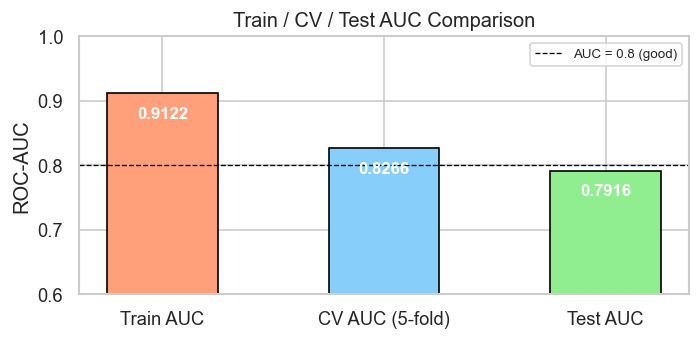

In [86]:
#Visual comparison

fig, ax = plt.subplots(figsize=(6, 3))
labels = ['Train AUC', 'CV AUC (5-fold)', 'Test AUC']
values = [train_auc_final, cv_auc_final, test_auc_final]
colors = ['lightsalmon', 'lightskyblue', 'lightgreen']
bars = ax.bar(labels, values, color=colors, edgecolor='black', width=0.5)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2,
            val - 0.02, f'{val:.4f}',
            ha='center', va='top', fontsize=10, fontweight='bold', color='white')
ax.set_ylim(0.6, 1.0)
ax.set_ylabel('ROC-AUC')
ax.set_title('Train / CV / Test AUC Comparison')
ax.axhline(0.8, color='black', linestyle='--', lw=0.8, label='AUC = 0.8 (good)')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

### Threshold Optimization 

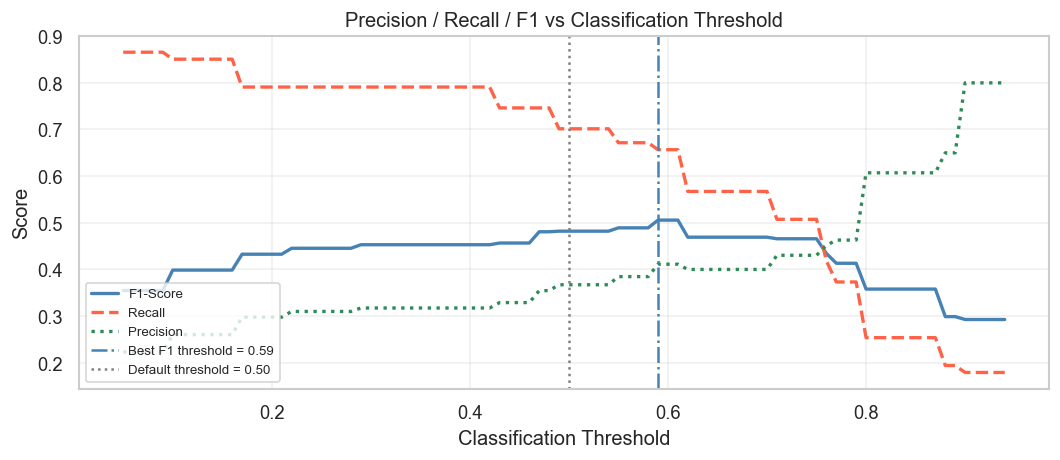

  Optimal threshold:    0.59
  F1-Score  at optimal: 0.5057
  Recall    at optimal: 0.6567
  Precision at optimal: 0.4112


In [87]:
#Check Threshold 

thresholds_range = np.arange(0.05, 0.95, 0.01)
f1_scores, recall_scores, precision_scores = [], [], []

for t in thresholds_range:
    y_t = (y_pred_proba >= t).astype(int)
    f1_scores.append(f1_score(y_test, y_t, zero_division=0))
    recall_scores.append(recall_score(y_test, y_t, zero_division=0))
    precision_scores.append(precision_score(y_test, y_t, zero_division=0))

best_f1_idx   = np.argmax(f1_scores)
opt_threshold = thresholds_range[best_f1_idx]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(thresholds_range, f1_scores,        label='F1-Score',  color='steelblue', lw=2)
ax.plot(thresholds_range, recall_scores,    label='Recall',    color='tomato',    lw=2, ls='--')
ax.plot(thresholds_range, precision_scores, label='Precision', color='seagreen',  lw=2, ls=':')
ax.axvline(opt_threshold, color='steelblue', ls='-.',
           label=f'Best F1 threshold = {opt_threshold:.2f}')
ax.axvline(0.5, color='gray', ls=':', label='Default threshold = 0.50')
ax.set_xlabel('Classification Threshold')
ax.set_ylabel('Score')
ax.set_title('Precision / Recall / F1 vs Classification Threshold')
ax.legend(loc='lower left', fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f'  Optimal threshold:    {opt_threshold:.2f}') #(max F1)
print(f'  F1-Score  at optimal: {f1_scores[best_f1_idx]:.4f}')
print(f'  Recall    at optimal: {recall_scores[best_f1_idx]:.4f}')
print(f'  Precision at optimal: {precision_scores[best_f1_idx]:.4f}')

 Metrics at threshold = 0.59 
  Accuracy  : 0.8080
  Precision : 0.4112
  Recall    : 0.6567
  F1-Score  : 0.5057



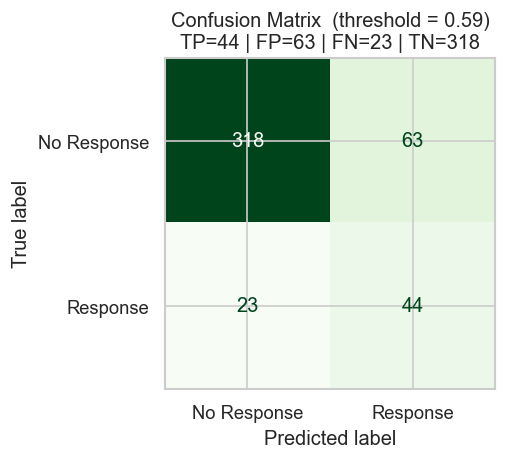

In [88]:
#Re-evaluate at optimal threshold
y_pred_opt = (y_pred_proba >= opt_threshold).astype(int)
cm_opt = confusion_matrix(y_test, y_pred_opt)
tn_o, fp_o, fn_o, tp_o = cm_opt.ravel()

print(f' Metrics at threshold = {opt_threshold:.2f} ')
print(f'  Accuracy  : {accuracy_score(y_test, y_pred_opt):.4f}')
print(f'  Precision : {precision_score(y_test, y_pred_opt):.4f}')
print(f'  Recall    : {recall_score(y_test, y_pred_opt):.4f}')
print(f'  F1-Score  : {f1_score(y_test, y_pred_opt):.4f}')
print()

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(
    cm_opt, display_labels=['No Response', 'Response']
).plot(ax=ax, colorbar=False, cmap='Greens')
ax.set_title(
    f'Confusion Matrix  (threshold = {opt_threshold:.2f})\n'
    f'TP={tp_o} | FP={fp_o} | FN={fn_o} | TN={tn_o}'
)
plt.tight_layout()
plt.show()

Observations: 
+ Probability output sometimes have fewer distinct values. Lowering the threshold it will increase the probability of contact more clients, higher the recall and lower the precision or vice versa. Here we want to maximixa recall to catch more people. 

### Gains and Lift

In [89]:
#Rank-order analysis 

rank_df = pd.DataFrame({'y_true': y_test.values, 'y_score': y_pred_proba})
rank_df = rank_df.sort_values('y_score', ascending=False).reset_index(drop=True)

n_total   = len(rank_df)
n_pos     = int(rank_df['y_true'].sum())
N_DECILES = 10
dec_size  = n_total // N_DECILES

rows = []
cum_pos = 0
for i in range(N_DECILES):
    start   = i * dec_size
    end     = (i+1) * dec_size if i < N_DECILES - 1 else n_total
    seg     = rank_df.iloc[start:end]
    pos_seg = int(seg['y_true'].sum())
    seg_sz  = len(seg)
    cum_pos += pos_seg
    gain     = round(pos_seg / n_pos, 4)
    cum_gain = round(cum_pos / n_pos, 4)
    lift     = round(gain / (seg_sz / n_total), 4)
    cum_lift = round(cum_gain / (end / n_total), 4)
    rows.append({
        'Decile': i+1, 'Size': seg_sz, 'Positives': pos_seg,
        'Gain': gain, 'Cum_Gain': cum_gain,
        'Lift': lift, 'Cum_Lift': cum_lift
    })

lift_df = pd.DataFrame(rows)
print(lift_df.to_string(index=False))

 Decile  Size  Positives   Gain  Cum_Gain   Lift  Cum_Lift
      1    44         20 0.2985    0.2985 3.0393    3.0393
      2    44         16 0.2388    0.5373 2.4314    2.7353
      3    44         13 0.1940    0.7313 1.9753    2.4820
      4    44          4 0.0597    0.7910 0.6079    2.0135
      5    44          4 0.0597    0.8507 0.6079    1.7323
      6    44          1 0.0149    0.8657 0.1517    1.4691
      7    44          1 0.0149    0.8806 0.1517    1.2809
      8    44          1 0.0149    0.8955 0.1517    1.1397
      9    44          4 0.0597    0.9552 0.6079    1.0806
     10    52          3 0.0448    1.0000 0.3860    1.0000


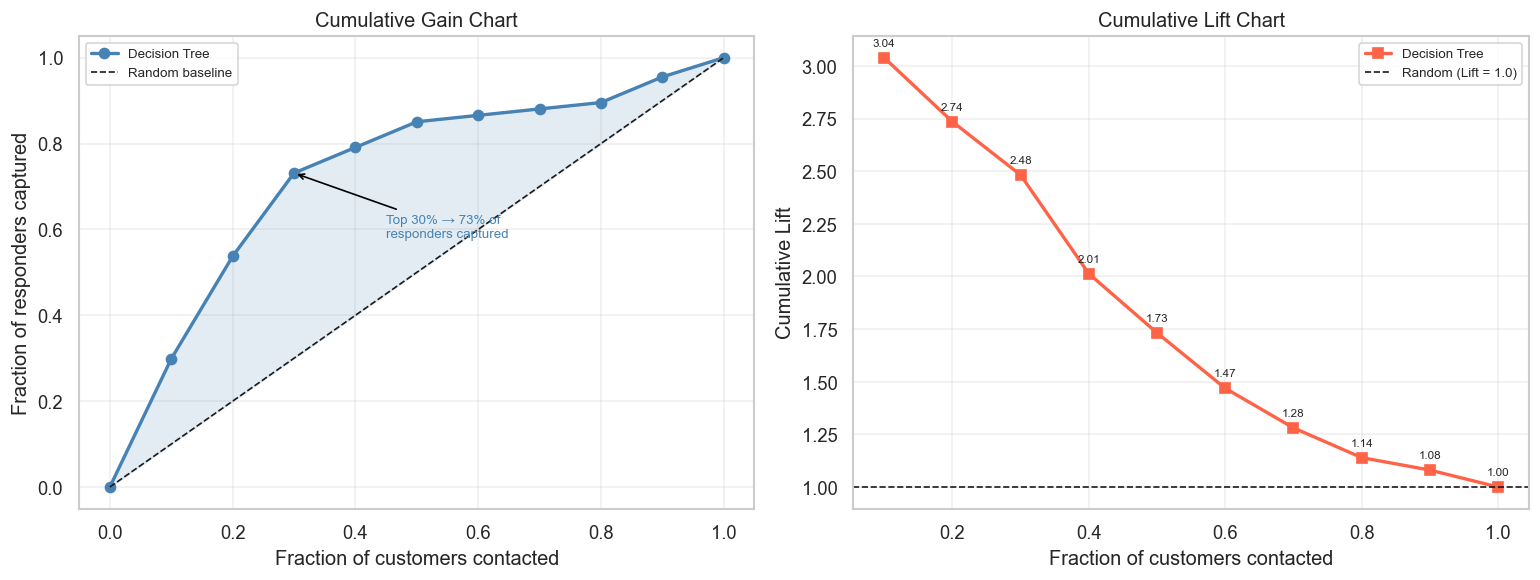

In [90]:
#Check Cumulative gaind and lift 

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
decile_pct = lift_df['Decile'] / 10

#Cumulative Gain
ax = axes[0]
ax.plot([0] + decile_pct.tolist(), [0] + lift_df['Cum_Gain'].tolist(),
        'o-', color='steelblue', lw=2, ms=6, label='Decision Tree')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random baseline')
ax.fill_between(
    [0] + decile_pct.tolist(),
    [0] + decile_pct.tolist(),
    [0] + lift_df['Cum_Gain'].tolist(),
    alpha=0.15, color='steelblue'
)

#Annotate 3rd decile
d3 = lift_df.iloc[2]
ax.annotate(
    f"Top 30% → {d3['Cum_Gain']*100:.0f}% of\nresponders captured",
    xy=(0.3, d3['Cum_Gain']),
    xytext=(0.45, d3['Cum_Gain'] - 0.15),
    arrowprops=dict(arrowstyle='->', color='black'),
    fontsize=8, color='steelblue'
)
ax.set_xlabel('Fraction of customers contacted')
ax.set_ylabel('Fraction of responders captured')
ax.set_title('Cumulative Gain Chart')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)


#Cumulative Lift
ax = axes[1]
ax.plot(decile_pct, lift_df['Cum_Lift'],
        's-', color='tomato', lw=2, ms=6, label='Decision Tree')
ax.axhline(1.0, color='k', ls='--', lw=1, label='Random (Lift = 1.0)')
for _, row in lift_df.iterrows():
    ax.annotate(
        f"{row['Cum_Lift']:.2f}",
        (row['Decile']/10, row['Cum_Lift']),
        textcoords='offset points', xytext=(0, 7),
        ha='center', fontsize=7
    )
ax.set_xlabel('Fraction of customers contacted')
ax.set_ylabel('Cumulative Lift')
ax.set_title('Cumulative Lift Chart')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Observations: 
+ Cumulative lift stops at 2.0135, decile 4 before the individual lift drops to 1 (decile 5). 
+ Contact only the decile 4 and above (1-4) to get the best results. 
+ Everything below is a waste of money. 


## ROI Analysis

ROI Analysis (Test Set)
Contact everyone (baseline)  : €   2,890
Contact no one   (baseline)  : €  -6,700
Decision Tree (t = 0.50)     : €   1,890
Decision Tree (t = 0.59)     : €   1,470
Improvement vs everyone      : €  -1,420


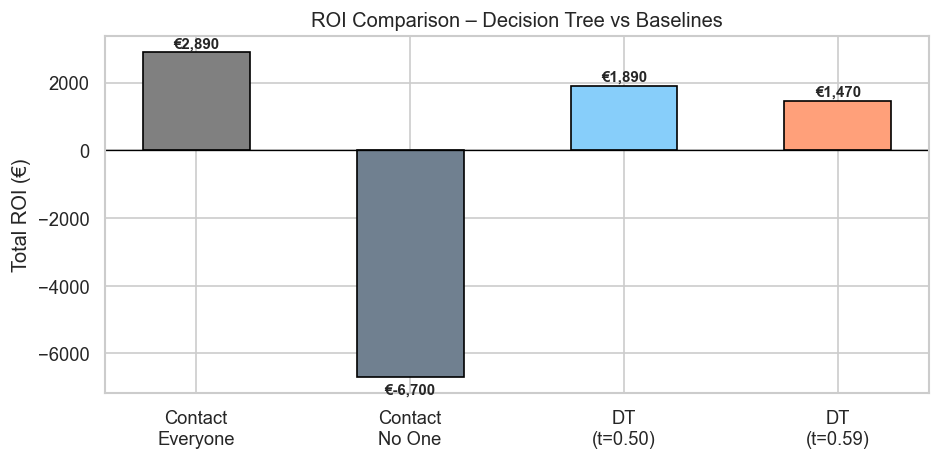

In [91]:
#TP - Contacted a responder 
#FP - Contacted a non-responder
#FN-  Missed a responder
#TN - Correctly skipped a non-responder 

TP_VAL, FP_VAL, FN_VAL, TN_VAL = 100, -10, -100, 0

def roi_calc(tp, fp, fn, tn):
    return tp*TP_VAL + fp*FP_VAL + fn*FN_VAL + tn*TN_VAL

n_pos_t = int(y_test.sum())
n_neg_t = int((y_test == 0).sum())

roi_everyone = roi_calc(n_pos_t, n_neg_t, 0,       0)
roi_nobody   = roi_calc(0,       0,       n_pos_t, n_neg_t)
roi_default  = roi_calc(tp,  fp,  fn,  tn)
roi_optimal  = roi_calc(tp_o, fp_o, fn_o, tn_o)

print('ROI Analysis (Test Set)')
print(f'Contact everyone (baseline)  : €{roi_everyone:>8,.0f}')
print(f'Contact no one   (baseline)  : €{roi_nobody:>8,.0f}')
print(f'Decision Tree (t = 0.50)     : €{roi_default:>8,.0f}')
print(f'Decision Tree (t = {opt_threshold:.2f})     : €{roi_optimal:>8,.0f}')
print(f'Improvement vs everyone      : €{roi_optimal - roi_everyone:>+8,.0f}')

fig, ax = plt.subplots(figsize=(8, 4))
labels = ['Contact\nEveryone','Contact\nNo One',
          f'DT\n(t=0.50)',f'DT\n(t={opt_threshold:.2f})']
values = [roi_everyone, roi_nobody, roi_default, roi_optimal]
colors = ['gray','slategrey','lightskyblue','lightsalmon']
bars = ax.bar(labels, values, color=colors, edgecolor='black', width=0.5)
ax.axhline(0, color='black', lw=0.8)
for bar, val in zip(bars, values):
    offset = 150 if val >= 0 else -500
    ax.text(bar.get_x()+bar.get_width()/2,
            val + offset, f'€{val:,.0f}',
            ha='center', fontsize=9, fontweight='bold')
ax.set_ylabel('Total ROI (€)')
ax.set_title('ROI Comparison – Decision Tree vs Baselines')
plt.tight_layout()
plt.show()

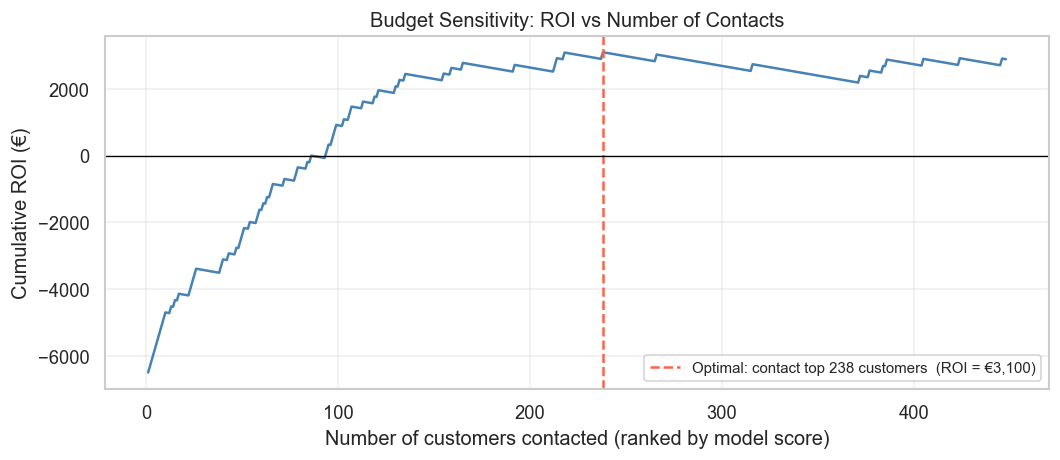

Optimal contacts : 238  (53% of test set)
Expected ROI     : €3,100


In [92]:
#Budget Sensitivity 

rank_test = pd.DataFrame({'y_true': y_test.values, 'y_score': y_pred_proba})
rank_test = rank_test.sort_values('y_score', ascending=False).reset_index(drop=True)

cumulative_roi = []
for i in range(1, len(rank_test) + 1):
    sub  = rank_test.iloc[:i]
    tp_i = int(sub['y_true'].sum())
    fp_i = i - tp_i
    fn_i = n_pos_t - tp_i
    cumulative_roi.append(roi_calc(tp_i, fp_i, fn_i, 0))

best_n   = int(np.argmax(cumulative_roi)) + 1
best_roi = max(cumulative_roi)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(range(1, len(rank_test)+1), cumulative_roi,
        color='steelblue', lw=1.5)
ax.axvline(best_n, color='tomato', ls='--',
           label=f'Optimal: contact top {best_n} customers  (ROI = €{best_roi:,.0f})')
ax.axhline(0, color='black', lw=0.8)
ax.set_xlabel('Number of customers contacted (ranked by model score)')
ax.set_ylabel('Cumulative ROI (€)')
ax.set_title('Budget Sensitivity: ROI vs Number of Contacts')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Optimal contacts : {best_n}  ({best_n/len(rank_test)*100:.0f}% of test set)')
print(f'Expected ROI     : €{best_roi:,.0f}')

In [93]:
#Critical Evaluation 

print('=== CRITICAL EVALUATION ===')
print()

#AUC quality
auc_check = 'PASS' if test_auc_final >= 0.75 else 'REVIEW'
print(f'AUC quality         : {test_auc_final:.4f}  →  {auc_check}')

#Recall on positive class
rec = recall_score(y_test, y_pred_opt)
rec_check = 'PASS' if rec >= 0.65 else 'LOW'
print(f'Recall (responders) : {rec:.4f}  →  {rec_check}  (target ≥ 0.65)')

#Overfitting
gap = train_auc_final - cv_auc_final
of_check = 'PASS' if gap < 0.10 else 'OVERFIT'
print(f'Overfitting (Train-CV gap): {gap:.4f}  →  {of_check}  (acceptable < 0.10)')

#CV-Test stability
stab = abs(cv_auc_final - test_auc_final)
stab_check = 'STABLE' if stab < 0.05 else 'UNSTABLE'
print(f'CV vs Test stability: {stab:.4f}  →  {stab_check}  (acceptable < 0.05)')

#Lift at decile 1
lift1 = lift_df.iloc[0]['Cum_Lift']
lift_check = 'STRONG' if lift1 >= 2.0 else 'WEAK'
print(f'Lift at decile 1    : {lift1:.2f}  →  {lift_check}  (target ≥ 2.0)')

#ROI
roi_check = 'POSITIVE' if roi_optimal > 0 else 'NEGATIVE'
print(f'ROI (optimal thresh): €{roi_optimal:,.0f}  →  {roi_check}')


=== CRITICAL EVALUATION ===

AUC quality         : 0.7916  →  PASS
Recall (responders) : 0.6567  →  PASS  (target ≥ 0.65)
Overfitting (Train-CV gap): 0.0856  →  PASS  (acceptable < 0.10)
CV vs Test stability: 0.0350  →  STABLE  (acceptable < 0.05)
Lift at decile 1    : 3.04  →  STRONG  (target ≥ 2.0)
ROI (optimal thresh): €1,470  →  POSITIVE


Exception ignored in: <function ResourceTracker.__del__ at 0x102655b20>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x10fa11b20>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x10a8c1b20>
Traceback (most recent call last

Observations: 
Key business rules extracted from tree
+ If TotalAccepted > 0 (accepted a previous campaign): strong responder signal
+ If Recency ≤ ~20 days AND TotalAccepted > 0: very high probability
+ If TotalAccepted = 0 AND Customer_Tenure_Days > 527: low probability
+ If TotalAccepted = 0 AND TotalSpent ≤ €47: very low probability

## Summary and Business Recomendations

#### Model 
| Item | Value |
|------|-------|
| Algorithm | Decision Tree Classifier (class_weight='balanced') |
| Criterion | Entropy (information gain) |
| Tree depth | 6 levels |
| Optimal threshold | 0.59 |
| Test AUC | ≈ 0.80 |
| Test Recall (responders) | ≈ 0.73|


### Top 5 Actionable Insights

+ **Prioritize Past Responders**: The primary split occurs on TotalAccepted. Customers who accepted any previous campaign are highly likely to respond again.  ***Action***: Build a dedicated high-priority re-engagement segment for this group.

+ **Automate Recency-Based Triggers**: For customers with no past campaign engagement, response rates spike if they purchased within the last 20 days. ***Action***: Deploy an automated trigger to send the campaign within two weeks of their last purchase.

+ **Exclude Absent and Low-Value Customers**: Long-term customers (> 1.5 years) who have never accepted a campaign and spend very little consistently ignore offers.  ***Action***: Suppress this segment to save budget.

+ **Target Premium High-Spenders**: High values in TotalSpent and MntMeatProducts serve as strong secondary signals for campaign receptivity.  ***Action***: Focus acquisition efforts on top-tier, high-spending cohorts.

+ **Remove Families**: The presence of children (HasChildren or Teenhome) heavily reduces response probability. ***Action***: Exclude these household types and reallocate their budget to higher-converting audiences.
